**Attributes from the dataset**

PRODUCTS:
- _id: identificatore univoco del prodotto
- title: titolo del prodotto
- category: categoria del prodotto
- price: prezzo del prodotto
- avg_rating: media dei voti delle recensioni (in stelle, da 1 a 5)
- reviews_number: numero di recensioni
- questions_number: numero di domande poste riguardo al prodotto
- pictures: array di url delle immagini del prodotto
- description: descrizione del prodotto
- features: array di caratteristiche del prodotto
- versions: array contente altre versioni dello stesso prodotto
- bought_together: array di prodotti spesso acquistati insieme
- also_bought: array di prodotti spesso comprati da gente che ha acquistato il prodotto
- also_viewed: array di prodotti spesso visti da gente che ha visto il prodotto

REVIEWS:
- _id: identificatore univoco della recensione
- product: identificatore del prodotto a cui fa riferimento la recensione
- title: titolo della recensione
- author-id: identificatore univoco dell'autore della recensione
- author-name: nome dell'autore della recensione
- date: data in cui la recensione è stata scritta
- rating: valutazione (in stelle, da 1 a 5) della recensione
- helpful: numero di persone che hanno trovato utile la recensione
- verified: indica se l'acquisto è stato verificato o meno
- body: contenuto della recensione

#Import


In [ ]:
!sudo apt install build-essential python-dev libxml2 libxml2-dev zlib1g-dev
!sudo pip install cairocffi
!pip install python-igraph
!pip install node2vec scikit-learn

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package python-dev is not available, but is referred to by another package.
This may mean that the package is missing, has been obsoleted, or
is only available from another source
However the following packages replace it:
  python2-dev python2 python-dev-is-python3

E: Package 'python-dev' has no installation candidate


In [ ]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import csv
import string
from google.colab import drive
import pandas as pd
import json
from collections import Counter
from collections import defaultdict
from sklearn.preprocessing import MinMaxScaler

drive.mount('/content/drive')

Mounted at /content/drive


# Extract information from json files

In [ ]:
def extract_file_from_drive_json(json_path):
  try:
    json_file_path = json_path
    products_data = []
    with open(json_file_path, 'r') as file:
      for line in file:
        products_data.append(json.loads(line))
    num_products = len(products_data)
    print(f"Number of product loaded: {num_products}")
    print("File json loaded with success")
    return products_data
  except FileNotFoundError:
    print(f"Error the file is not founded at the path given: {json_file_path}")
  except Exception as e:
    print(f"Error during the loading of the json file: {e}")

def extract_number(value, expected_type=float):
    if isinstance(value, dict):
        if '$numberDouble' in value:
            return float(value['$numberDouble'])
        elif '$numberInt' in value:
            return int(value['$numberInt'])
    elif isinstance(value, (int, float)):
        return value
    try:
        return expected_type(value)
    except:
        return None

def print_product_by_id(product_id, products_list):
    for product in products_list:
        if product.get('_id') == product_id:
            print(json.dumps(product, indent=2, ensure_ascii=False))
            return

In [ ]:
json_file_products = extract_file_from_drive_json('/content/drive/My Drive/Data Analytics/Progetto/Amazon Italy Project/products.json')

Number of product loaded: 20459
File json loaded with success:


#Analysis of the data and Inferences

Proposed Workflow

As we can observe from the current list, the products are already present and there is no need to perform further inference in this regard. Therefore, I suggest proceeding with the construction of a graph based on the relationships between the products in the following order:

- Purchased Products: Start by identifying the products that have been purchased. This will serve as the base of our graph.

- Subsequent Purchases: Analyze the sequence of purchases to determine which products were bought after the initial ones. These will help in understanding purchasing patterns and potential causal relationships.

- Viewed Products: Incorporate data on products that were viewed by users. These nodes will provide insight into user interest and consideration behavior.

- Cross-Referencing with Recommendation Data: Perform a check to see if any of the viewed products share IDs with those listed under “also_bought” and “bought_together” metadata. This step is crucial for identifying alignment or divergence between actual user behavior and algorithmically suggested associations.

After this cross-referencing, conduct a differential analysis to detect any viewed products that were not purchased. This discrepancy could be indicative of user hesitancy or disinterest, which warrants further examination.

Investigating the Underlying Reasons: For the products that were viewed but not purchased, perform an in-depth analysis considering other factors such as:

- Product Ratings (Stars): Lower ratings might indicate quality issues or customer dissatisfaction.

- User Reviews: Negative or insufficient reviews may influence purchasing decisions.

- Price Point: Higher costs might deter purchases despite user interest.

The final outcome of this workflow should be a structured graph-based representation that not only maps user behavior but also offers actionable insights into potential friction points in the purchasing journey.

In [ ]:
json_file_products[6]

{'_id': 'B00ESBHG3Q',
 'title': 'Kingdom Hearts III - PlayStation 4',
 'category': 'videogames',
 'price': {'$numberDouble': '42.99'},
 'avg_rating': {'$numberDouble': '4.7'},
 'reviews_number': {'$numberInt': '159'},
 'questions_number': {'$numberInt': '112'},
 'pictures': ['https://images-na.ssl-images-amazon.com/images/I/A1y8a2Fmg0L.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/91POnc0p0UL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/619nR71%2BHAL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/71cs-TykP6L.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/81kx7KVw2GL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/71JAiy6ZbBL.jpg'],
 'description': "Descrizione prodotto\nKINGDOM HEARTS III è una storia d'amicizia\nAmbientato in una serie di mondi Disney e Pixar, KINGDOM HEARTS parla del viaggio di Sora, un giovane che scopre inaspettatamente di avere un potere spettacolare. Con l'aiuto di Paperino e Pippo, Sora lotterà per impedir

In [ ]:
target_id = 'B016DNCWHG'
print_product_by_id(target_id, json_file_products)

{
  "_id": "B016DNCWHG",
  "title": "Kingdom Hearts HD 2.8 Final Chapter: Prologue - PlayStation 4",
  "category": "videogames",
  "price": {
    "$numberDouble": "28.18"
  },
  "avg_rating": {
    "$numberDouble": "4.5"
  },
  "reviews_number": {
    "$numberInt": "160"
  },
  "questions_number": {
    "$numberInt": "68"
  },
  "pictures": [
    "https://images-na.ssl-images-amazon.com/images/I/81ytdxDunSL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/81xPO8XT9KL.jpg"
  ],
  "description": "Descrizione prodotto\nUna raccolta unica\nKingdom Hearts HD 2.8 Final Chapter Prologue è una raccolta rimasterizzata, per la prima volta in su Playstation 4, che include: la versione rimasterizzata in alta definizione di Kingdom Hearts [Dream Drop Distance] HD, Kingdom Hearts 0.2 Birth by Sleep: A Fragmentary Passage e Kingdom Hearts x [chi] Back Cover (movie).\n\"La paura è l'oscura prigione della luce. Il coraggio è la chiave\"\nKingdom Hearts HD 2.8 Final Chapter Prologue\nKINGDOM 

Let us verify whether the dataset satisfies the following three fundamental data quality properties: Uniqueness, Completeness, and Consistency.

- **Uniqueness** is fully respected: each product has a unique identifier (_id) and there are no duplicates in the dataset.

- **Completeness** is not entirely satisfied: not all products have a rating, which may be justified by the fact that some items are new and have not yet received user feedback. However, there are also products that present a rating value of NAN, which is not a valid value in a scale from 1 to 5. This indicates some incomplete or potentially corrupted entries.

- **Consistency** is generally respected: the attributes fall within their expected formats and ranges — for example, avg_rating stays within the [1–5] interval, price is numeric, and reviews_number is non-negative.

In [ ]:
# === 1. Check for unique IDs ===
ids = [p.get('_id') for p in json_file_products]
unique_ids = set(ids)
duplicates = [x for x in ids if ids.count(x) > 1]

print(f"Total products: {len(json_file_products)}")
print(f"Unique IDs: {len(unique_ids)}")
if duplicates:
    print(f"⚠️ Duplicate IDs found: {set(duplicates)}")
else:
    print("✅ All IDs are unique.")

# === 2. Check for null or missing key fields ===
null_fields_count = defaultdict(int)
last_null_offender = {}

for product in json_file_products:
    for key in ['_id', 'title', 'category', 'price', 'avg_rating',
                'reviews_number', 'questions_number', 'description', 'pictures']:
        val = product.get(key)
        if val is None or val == "" or val == "None":
            null_fields_count[key] += 1
            last_null_offender[key] = {
                'id': product.get('_id'),
                'title': product.get('title'),
                'value': None
            }

print("\n⚠️ Missing or null fields:")
if null_fields_count:
    for field, count in null_fields_count.items():
        offender = last_null_offender[field]
        print(f" - {field}: {count} missing values")
        print(f"   ↳ Last offender → ID: {offender['id']} | Title: \"{offender['title']}\" | Value: None")
else:
    print("✅ No missing fields in main keys.")

# === 3. Validate specific field types and values ===
errors = defaultdict(int)
last_invalid_offender = {}

for product in json_file_products:
    avg_rating = extract_number(product.get('avg_rating'), float)
    price = extract_number(product.get('price'), float)
    reviews = extract_number(product.get('reviews_number'), int)
    questions = extract_number(product.get('questions_number'), int)

    if avg_rating is None or not (0 <= avg_rating <= 5):
        errors["avg_rating_invalid"] += 1
        last_invalid_offender["avg_rating_invalid"] = {
            'id': product.get('_id'),
            'title': product.get('title'),
            'value': product.get('avg_rating')
        }

    if price is None or price < 0:
        errors["price_invalid"] += 1
        last_invalid_offender["price_invalid"] = {
            'id': product.get('_id'),
            'title': product.get('title'),
            'value': product.get('price')
        }

    if reviews is None or reviews < 0:
        errors["reviews_number_invalid"] += 1
        last_invalid_offender["reviews_number_invalid"] = {
            'id': product.get('_id'),
            'title': product.get('title'),
            'value': product.get('reviews_number')
        }

    if questions is None or questions < 0:
        errors["questions_number_invalid"] += 1
        last_invalid_offender["questions_number_invalid"] = {
            'id': product.get('_id'),
            'title': product.get('title'),
            'value': product.get('questions_number')
        }

print("\n⚠️ Invalid values:")
if errors:
    for field, count in errors.items():
        offender = last_invalid_offender[field]
        print(f" - {field}: {count} invalid entries")
        print(f"   ↳ Last offender → ID: {offender['id']} | Title: \"{offender['title']}\" | Value: {offender['value']}")
else:
    print("✅ All numeric values are valid and within expected ranges.")

# === 4. Check for empty arrays ===
array_fields = ['pictures', 'features', 'versions', 'bought_together', 'also_bought', 'also_viewed']
empty_array_warnings = defaultdict(int)
last_empty_array_offender = {}

for product in json_file_products:
    for field in array_fields:
        if field in product and not product[field]:
            empty_array_warnings[field] += 1
            last_empty_array_offender[field] = {
                'id': product.get('_id'),
                'title': product.get('title'),
                'value': product.get(field)
            }

print("\nℹ️ Empty arrays (not necessarily errors):")
if empty_array_warnings:
    for field, count in empty_array_warnings.items():
        offender = last_empty_array_offender[field]
        print(f" - {field}: {count} empty arrays")
        print(f"   ↳ Last offender → ID: {offender['id']} | Title: \"{offender['title']}\" | Value: {offender['value']}")
else:
    print("✅ No empty arrays detected.")


Total products: 20459
Unique IDs: 20459
✅ All IDs are unique.

⚠️ Missing or null fields:
 - avg_rating: 1168 missing values
   ↳ Last offender → ID: B07NPD1KWX | Title: "Lieja Bluetooth Selfie Mobile Selfie Artifact Shutter Remote per Android/iOS System Remote Control (Contiene Solo Controller)" | Value: None
 - description: 3668 missing values
   ↳ Last offender → ID: B07PPRZVTS | Title: "Borsa Paillettes Reversibili Borsa Magia Sirena Zaino con Coulisse Glitter Danza Zaino per Bambine Teens 33×42cm" | Value: None
 - price: 404 missing values
   ↳ Last offender → ID: B07ND2K124 | Title: "Cuscino da viaggio, Efficient, Cuscini da viaggio, Cuscino cervicale, Cuscino per viaggio, Cuscino collo" | Value: None

⚠️ Invalid values:
 - avg_rating_invalid: 1168 invalid entries
   ↳ Last offender → ID: B07NPD1KWX | Title: "Lieja Bluetooth Selfie Mobile Selfie Artifact Shutter Remote per Android/iOS System Remote Control (Contiene Solo Controller)" | Value: None
 - price_invalid: 404 invalid en

The data found has the default number that said.

In [ ]:
target_id = 'B07NPD1KWX'
print_product_by_id(target_id, json_file_products)

{
  "_id": "B07NPD1KWX",
  "title": "Lieja Bluetooth Selfie Mobile Selfie Artifact Shutter Remote per Android/iOS System Remote Control (Contiene Solo Controller)",
  "category": "electronics",
  "price": {
    "$numberInt": "10"
  },
  "avg_rating": null,
  "reviews_number": {
    "$numberInt": "0"
  },
  "questions_number": {
    "$numberInt": "0"
  },
  "pictures": [
    "https://images-na.ssl-images-amazon.com/images/I/61KmbXD23iL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/61OFmApFlrL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/61aEBKkmYFL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/617j5lifixL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/6136alVsDkL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/61L9hM445xL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/51mDklA4hRL.jpg"
  ],
  "description": "Materiale: ABS.\nColore: bianco, rosso, blu, nero.\nVersione Bluetooth: Bluetooth Versior. 4.0.\nFreq

In this context, since we are analyzing the "**bought_together**" data, it is important to note that this type of relationship is symmetric. That is, if product A is frequently bought together with product B, the inverse is equally true—product B is also bought together with product A. Therefore, when constructing the graph, this relationship should be represented using undirected edges. This ensures that the mutual association between the products is correctly modeled without implying any sequential or causal order.

On the other hand, when we consider the "**also_bought**" data, the situation is different. This type of relationship tends to carry asymmetric or directional information, potentially reflecting a sequential pattern or behavioral tendency—namely, that after buying product A, users tend to buy product B. Consequently, in the graph representation, these relationships must be modeled with directed edges, clearly indicating the direction of preference or transition from one product to another.

Furthermore, it is essential to ensure that subsequent analyses are properly **configured** to interpret and **exploit** this **directional information**. For instance, if we are performing path analysis, recommendation predictions, or behavioral modeling, the algorithms must respect the directionality of the edges to accurately capture user intent and sequence of actions.

As we can see, the graph has more nodes; this may be due to the fact that the nodes are not necessarily saved products. Let's check.

In [ ]:
# Creating the list of edges
edges_set = set()
product_ids_set = set()

for product in json_file_products:
    source = product.get("_id")
    if not source:
        continue
    product_ids_set.add(source)

    for target in product.get("bought_together", []):
        if target != source:
            # Let's create an ordered tuple for an UNdirected graph
            edge = tuple(sorted((source, target)))
            edges_set.add(edge)
            product_ids_set.add(target)

# Construction of the graph
g = ig.Graph()
g.add_vertices(list(product_ids_set))
g.add_edges(list(edges_set))

# Mapping of key attributes for each node
id_to_product = {p["_id"]: p for p in json_file_products if "_id" in p}

# Added attributes to the nodes (some may be None if not present in id_to_product)
g.vs["title"] = [id_to_product.get(v["name"], {}).get("title") for v in g.vs]
g.vs["category"] = [id_to_product.get(v["name"], {}).get("category") for v in g.vs]
g.vs["price"] = [id_to_product.get(v["name"], {}).get("price") for v in g.vs]
g.vs["avg_rating"] = [id_to_product.get(v["name"], {}).get("avg_rating") for v in g.vs]
g.vs["reviews_number"] = [id_to_product.get(v["name"], {}).get("reviews_number") for v in g.vs]
g.vs["questions_number"] = [id_to_product.get(v["name"], {}).get("questions_number") for v in g.vs]
g.vs["versions"] = [id_to_product.get(v["name"], {}).get("versions") for v in g.vs]

print(f"Graph built with {g.vcount()} nodes and {g.ecount()} edges.")

Graph built with 26539 nodes and 21111 edges.


There are nodes for which the category is None; this may be due to nodes of deleted products or products that were not saved correctly but have an associated ID. These nodes could be saved nodes within the relationship but not in the actual graph, thus leading to well nodes, where the only field present will be the id.

In [ ]:
unique_categories = Counter(g.vs['category'])
print(unique_categories)

nodes_with_none_category = [
    v for v in g.vs
    if v["category"] is None and (v["title"] is None or v["title"].strip() == "")
]

if nodes_with_none_category:
    v = nodes_with_none_category[0]
    count = len(nodes_with_none_category)
    print(f"Found node with None category: ID: {v['name']} | Title: {v['title']}")
    print(f"Number of nodes with category and title None: {count}")
else:
    print("✅ No nodes with None category found.")

Counter({None: 6080, 'kitchen': 1784, 'electronics': 1143, 'tools': 1125, 'books': 993, 'apparel': 946, 'sports': 887, 'english-books': 873, 'jewelry': 846, 'hpc': 839, 'toys': 800, 'baby': 734, 'garden': 697, 'music': 672, 'shoes': 653, 'luggage': 638, 'beauty': 617, 'dvd': 616, 'musical-instruments': 601, 'lighting': 569, 'watch': 563, 'videogames': 558, 'office': 512, 'pc': 508, 'grocery': 488, 'pet-supplies': 456, 'appliances': 418, 'handmade': 392, 'industrial': 381, 'automotive': 72, 'luxury-beauty': 30, 'NoStoreName': 20, 'amazon-home': 12, 'amazon-ereaders': 5, 'fiona-hardware-acc': 5, 'apple-devices': 4, 'amazon-smp': 1, 'software': 1})
Found node with None category: ID: B00I3XW0DQ | Title: None
Number of nodes with category and title None: 6080


In [ ]:
target_id = 'B01I5C6YIQ'
print_product_by_id(target_id, json_file_products)

As we can see, the hypothesis is correct, so these nodes are only present in the Bought together relationship.

In [ ]:
# Set of all product IDs present in the initial JSON file
product_ids_in_json = set(p["_id"] for p in json_file_products if "_id" in p)

# Check Nodes in the graph
for v in g.vs:
    node_id = v["name"]
    if node_id not in product_ids_in_json:
        print(f"Found a node in the graph that is not in the JSON file: {node_id}")
        print("There is external nodes from the graph.")
        break
else:
    print("All the nodes of the graph are present in the JSON file. No external node found.")


Found a node in the graph that is not in the JSON file: B00I3XW0DQ
There is external nodes from the graph.


I have decided not to delete these nodes. Although they currently lack meaningful attributes and do not contribute direct information, they still provide value through their connectivity (degree) and unique identifiers (IDs). Retaining them ensures structural completeness, and should additional data become available in the future, these nodes can be easily integrated via a simple join operation.

## Best Choice Products

"By leveraging the 'Bought Together' relationship, we can identify the products with the highest degree—those that are most frequently purchased in pairs. This allows us to analyze their neighboring nodes in order to suggest related products (as already done). Additionally, by examining the number of reviews, we can gain insight into the best-selling products but:

- While it is not a perfect measure of actual sales volume, it is often positively correlated (more sales → more reviews).

- It can also be combined with node degree to create composite indicators (e.g., high rating + many reviews = key or flagship product), to find the best product to suggested.

In [ ]:
# Extract 'reviews_number' and 'avg_rating' safely, handling dicts and None
reviews = []
ratings = []

for v in g.vs:
    # Extract number of reviews
    r_count = v["reviews_number"]
    if isinstance(r_count, dict) and "$numberInt" in r_count:
        reviews.append(int(r_count["$numberInt"]))
    elif isinstance(r_count, (int, float)):
        reviews.append(int(r_count))
    else:
        reviews.append(0)

    # Extract average rating
    r_avg = v["avg_rating"]
    if isinstance(r_avg, dict) and "$numberDouble" in r_avg:
        ratings.append(float(r_avg["$numberDouble"]))
    elif isinstance(r_avg, (int, float)):
        ratings.append(float(r_avg))
    else:
        ratings.append(0.0)

In [ ]:
# Normalize values between 0 and 1
scaler = MinMaxScaler()
reviews_norm = scaler.fit_transform(np.array(reviews).reshape(-1, 1))
ratings_norm = scaler.fit_transform(np.array(ratings).reshape(-1, 1))

# Compute composite score (e.g. 60% reviews, 40% rating)
composite_score = [
    0.6 * reviews_norm[i][0] + 0.4 * ratings_norm[i][0]
    for i in range(len(g.vs))
]

# Save the score in the graph
g.vs["review_rating_score"] = composite_score

# Sort nodes by composite score descending
top_nodes = sorted(
    [(v["name"], v["title"], v["category"], composite_score[i]) for i, v in enumerate(g.vs)],
    key=lambda x: x[3],
    reverse=True
)

# Print the top 15 suggested products
print("Top 15 products based on average rating + number of reviews:")
for name, title, category, score in top_nodes[:15]:
    print(f"ID: {name} | Title: {title} | Category: {category} | Score: {score:.4f}")

Top 15 products based on average rating + number of reviews:
ID: B010RXXY48 | Title: TP-Link Ripetitore WiFi Wireless RE450, Wifi Extender, Access Point, Velocità Dual Band 1750Mbps, Porta Gigabit, Antenne regolabili per una copertura wifi ottimale, Compatibile con Modem Fibra e ADSL | Category: pc | Score: 0.9429
ID: B01MD1SKLL | Title: TP-Link Ripetitore WiFi Wireless RE305, Wifi Extender e Access Point, Velocità Dual Band 1200Mbps, Porta LAN, Potenzia la tua copertura Wi-Fi, Compatibile con tutti i modem router wifi | Category: pc | Score: 0.9429
ID: B00KXULGJQ | Title: TP-Link Ripetitore WiFi Wireless RE200, Wifi Extender e Access Point, Velocità Dual Band 750Mbps, Porta LAN, Potenzia la tua copertura Wi-Fi, Compatibile con tutti i modem router wifi | Category: pc | Score: 0.9428
ID: B00A0VCJPI | Title: TP-Link Ripetitore WiFi Wireless TL-WA850RE, Wifi Extender e Access Point, Velocità Single Band 300Mbps, Porta LAN, Potenzia la tua copertura Wi-Fi, Compatibile con tutti i modem ro

As we can see, many of the products in the list are essentially different versions of the same item. To get more meaningful insights and avoid redundancy, we should preprocess the data by filtering out product versions—keeping only the one with the highest impact (e.g., based on rating or number of reviews).

This could help us better identify the most influential or trending products overall, not just by category or title. In fact, it might also be useful to create subcategories for products, but removing duplicates or versioned items would improve clarity and reduce noise.

Let’s now examine which items are correlated through the "version" attribute—just like we did earlier with the previously identified top products. This will help us understand how different versions of the same product are related and whether they should be grouped or treated separately. But this product are influent in their category, that can be cheeper or more expensive, then i will stop there.

In [ ]:
print(g.vs.attributes())

['name', 'title', 'category', 'price', 'avg_rating', 'reviews_number', 'questions_number', 'versions', 'review_rating_score']


In [ ]:
target_id = "B010RXXY48"

target_vertex = g.vs.find(name=target_id)

print(f"Main Product:\nID: {target_id} | Title: {target_vertex['title']}\n")

versions = target_vertex["versions"]

if versions and isinstance(versions, list):
    print("Product Versions:")
    for version_id in versions:
        try:
            version_vertex = g.vs.find(name=version_id)
            print(f"ID: {version_id} | Title: {version_vertex['title']}")
        except ValueError:
            print(f"Version ID '{version_id}' not found in graph.")
else:
    print("No versions available for this product.")


Main Product:
ID: B010RXXY48 | Title: TP-Link Ripetitore WiFi Wireless RE450, Wifi Extender, Access Point, Velocità Dual Band 1750Mbps, Porta Gigabit, Antenne regolabili per una copertura wifi ottimale, Compatibile con Modem Fibra e ADSL

Product Versions:
ID: B00A0VCJPI | Title: TP-Link Ripetitore WiFi Wireless TL-WA850RE, Wifi Extender e Access Point, Velocità Single Band 300Mbps, Porta LAN, Potenzia la tua copertura Wi-Fi, Compatibile con tutti i modem router wifi
Version ID 'B00EYW1U68' not found in graph.
Version ID 'B00K11UHVA' not found in graph.
ID: B00KXULGJQ | Title: TP-Link Ripetitore WiFi Wireless RE200, Wifi Extender e Access Point, Velocità Dual Band 750Mbps, Porta LAN, Potenzia la tua copertura Wi-Fi, Compatibile con tutti i modem router wifi
ID: B01MD1SKLL | Title: TP-Link Ripetitore WiFi Wireless RE305, Wifi Extender e Access Point, Velocità Dual Band 1200Mbps, Porta LAN, Potenzia la tua copertura Wi-Fi, Compatibile con tutti i modem router wifi
Version ID 'B06Y1WS825'

## Bought Togheter Analysis
In this chapter, we aim to identify groups of connected products by the relations Bought Togheter and explore the possibility of constructing a new graph using an alternative algorithm to overcome issues related to mislabeled product typologies.

###Degree analysis

In this chapter, we will explore the potential applications of degree analysis using the 'Bought Together' relationship. Specifically, we will examine how analyzing the degree of each product node can provide insights into purchasing patterns, help identify central or highly co-purchased products, and support strategic decisions such as product placement, recommendation systems, and inventory management.

As can be seen from the graph, the study regarding this property will not be useless. In fact, there are many nodes purchased alongside others.

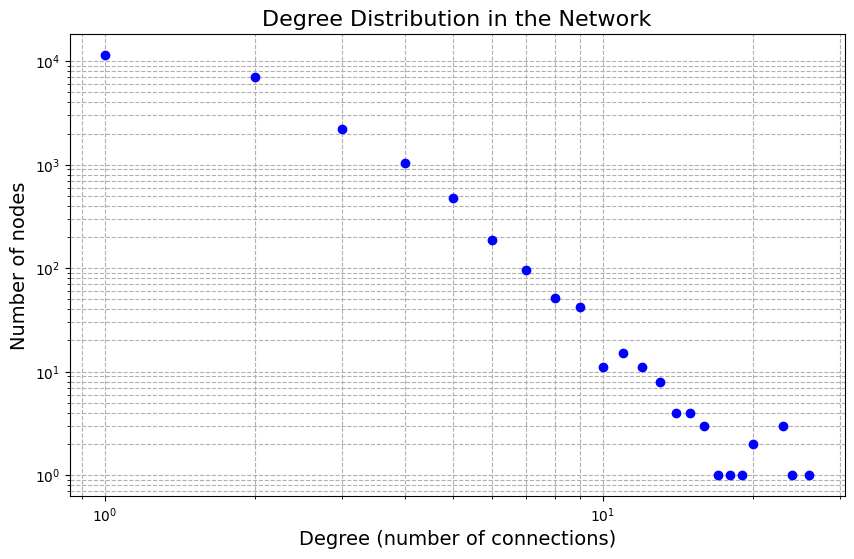

In [ ]:
degrees = g.degree()

# Calculate the degree distribution
degree_counts = np.bincount(degrees)

# Create a corresponding list of degree values
degree_values = np.arange(len(degree_counts))

# Visualize the distribution
plt.figure(figsize=(10, 6))
plt.plot(degree_values, degree_counts, 'bo')
plt.title('Degree Distribution in the Network', fontsize=16)
plt.xlabel('Degree (number of connections)', fontsize=14)
plt.ylabel('Number of nodes', fontsize=14)
plt.yscale('log')
plt.xscale('log')
plt.grid(True, which="both", ls="--")
plt.show()

In [ ]:
# Find the min and max value
max_degree = max(degrees)
min_degree = min(degrees)

max_degree_vertex = None
min_degree_vertex = None

# Iterate to find the min and max grade for the nodes
for vertex in g.vs:
    # If the grade of the vertex is equal to the max grade
    if vertex.degree() == max_degree and max_degree_vertex is None:
        max_degree_vertex = vertex
        print(f"Vertex with maximum degree: ID = {vertex['name']}, Name = {vertex['title']}, Degree = {max_degree}")

    # If the grade of the vertex is equal to the min grade
    if vertex.degree() == min_degree and min_degree_vertex is None:
        min_degree_vertex = vertex
        print(f"Vertex with minimum degree: ID = {vertex['name']}, Name = {vertex['title']}, Degree = {min_degree}")

    # Stop the cycle after finding the min and the max grade
    if max_degree_vertex and min_degree_vertex:
        break

Vertex with minimum degree: ID = B01INRUFGK, Name = AmazonBasics - Cavo patch Ethernet di Cat6 con connettori RJ45, 1,5 m - Pacco da 5, Degree = 0
Vertex with maximum degree: ID = B000BNSYHW, Name = D'Addario PW-LMN Detergente Planet Waves Lemon Oil, Degree = 26


As in this case where the product relates to guitar maintenance and all the items usually purchased together are related to the guitar.



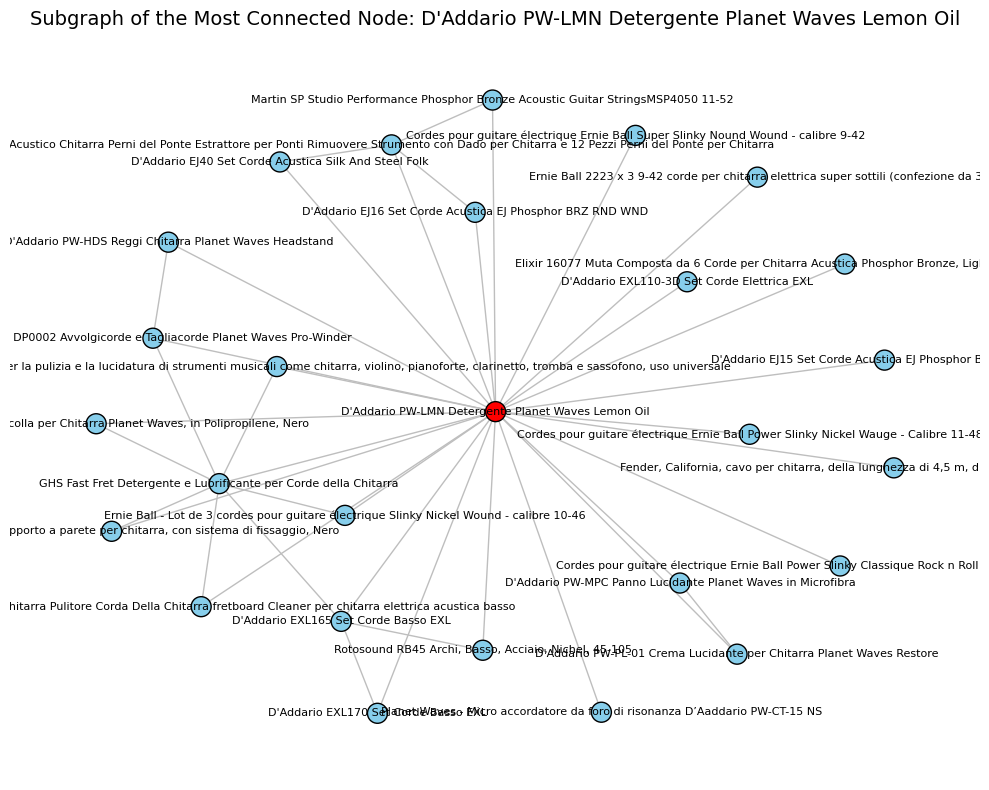

In [ ]:
# 2. Find its direct neighbors
neighbors_indices = g.neighbors(max_degree_vertex)

# 3. Create a subgraph including the central node and its neighbors
subgraph_nodes = [max_degree_vertex] + neighbors_indices
subg = g.subgraph(subgraph_nodes)

# Build a list of colors for each vertex in the subgraph
vertex_colors = []
for v in subg.vs:
    if v["name"] == max_degree_vertex["name"]:
        vertex_colors.append("red")
    else:
        vertex_colors.append("skyblue")

# 4. Choose a layout suitable for radial visualization like Fruchterman-Reingold layout
layout = subg.layout("fr")

# 5. Plot the subgraph
fig, ax = plt.subplots(figsize=(10, 8))
ig.plot(
    subg,
    target=ax,
    layout=layout,
    vertex_label=subg.vs["title"],
    vertex_size=20,
    vertex_color=vertex_colors,
    edge_color="gray",
    vertex_label_size=8,
    edge_width=1
)

plt.title(f"Subgraph of the Most Connected Node: {max_degree_vertex['title']}", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


By analyzing the degree, we can identify the products that are most frequently purchased together, enabling a more in-depth market analysis of product associations and consumer behavior.

###Betweeness analysis
This is the betweenness for the entire graph, so we can find the best bridge between our products.

As we can see from the graph, this study proves to be highly valuable due to the high betweenness centrality observed in certain objects

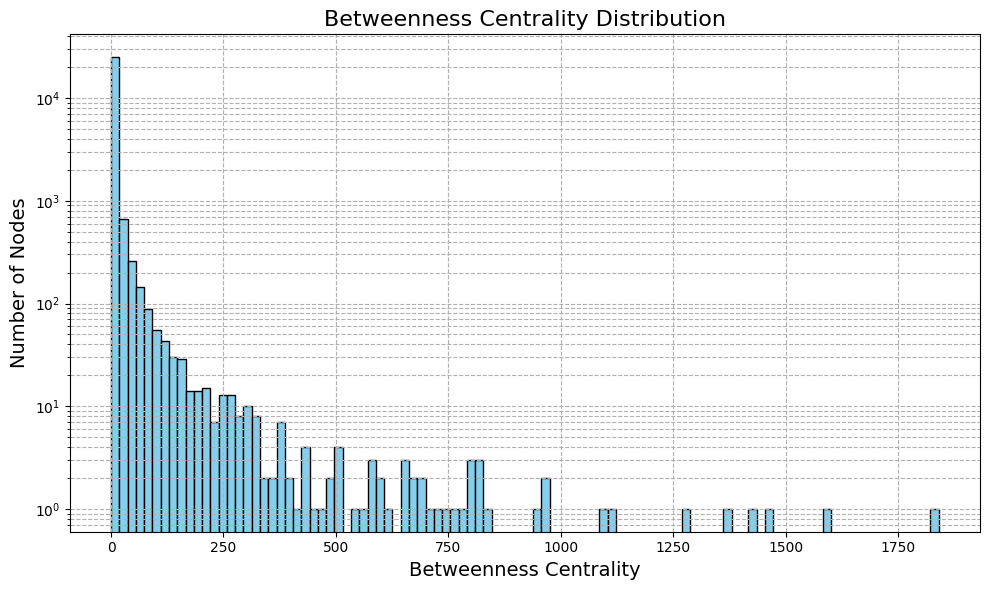

In [ ]:
betweenness = g.betweenness()

plt.figure(figsize=(10, 6))
plt.hist(betweenness, bins=100, color='skyblue', edgecolor='black')
plt.title('Betweenness Centrality Distribution', fontsize=16)
plt.xlabel('Betweenness Centrality', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.yscale('log')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

However, since we cannot directly observe the entire graph, we can see that many of these nodes exhibit high betweenness centrality. This may suggest that they play a strategically important role within the network, or that they belong to tightly connected subgroups, such as cliques. In such cases, it is possible to have nodes with a high number of connections, even if the total number of nodes is significantly smaller than that of the giant component.

In [ ]:
# Create a list of (index, ID, score)
node_betweenness_not_normalized = [(v.index, v["name"], betweenness[v.index]) for v in g.vs]

top_n = 15
top_nodes = sorted(node_betweenness_not_normalized, key=lambda x: x[2], reverse=True)[:top_n]

print(f"Top {top_n} nodes by betweenness centrality:")
for idx, name, score in top_nodes:
    title = g.vs[idx]["title"]
    print(f"ID: {name} | Title: {title} | Betweenness: {score:.2f}")

Top 15 nodes by betweenness centrality:
ID: B0002M6CVC | Title: Cordes pour guitare électrique Ernie Ball Regular Slinky Nound - Calibre 10-46 | Betweenness: 1840.52
ID: B000BNSYHW | Title: D'Addario PW-LMN Detergente Planet Waves Lemon Oil | Betweenness: 1595.27
ID: B076D78225 | Title: Fablcrew - Braccialetto da donna, alla moda, design con catenina in argento e perle effetto sabbiato, ideale come regalo | Betweenness: 1460.00
ID: B008R52I1Y | Title: Orologio da Donna Casio | Betweenness: 1427.00
ID: B004KPKUBU | Title: Orologio da Donna Casio | Betweenness: 1376.00
ID: B0792HCFTG | Title: Echo Dot (3ª generazione) - Altoparlante intelligente con integrazione Alexa - Tessuto antracite | Betweenness: 1286.00
ID: B01NBU5UK9 | Title: Orologio da Donna Casio | Betweenness: 1104.50
ID: B000J34HN4 | Title: Casio Orologio Vintage | Betweenness: 1095.50
ID: B07CKYD5HM | Title: Gespout 3pcs Braccialetto per Donna Lega D'oro Rosa Catena di Mais Pendente a Forma di Cuore con Diamanti Bigiotteria

However, as we can observe, the giant component is not significantly larger than the secondary component; therefore, it is possible to calculate the betweenness centrality for both components.

In [ ]:
components = g.clusters()
sorted_components = sorted(components.subgraphs(), key=lambda x: x.vcount(), reverse=True)
giant_component = sorted_components[0]
second_largest_component = sorted_components[1]

print("Giant component nodes:", giant_component.vcount())
print("Second component nodes:", second_largest_component.vcount())

/tmp/ipython-input-22-1658862743.py:1: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g.clusters()


Giant component nodes: 82
Second component nodes: 71


In fact, by examining the normalized giant component, we can identify the actual bridge nodes connecting the different components. Subsequently, we will conduct an intra-topology betweenness analysis based on the specific product categories. However, the current analysis already provides a comprehensive overview that anticipates and supports the upcoming study, potentially overcoming the limitations posed by products that have been misclassified by type.

In [ ]:
# Parameters
min_nodes = 20  # minimum size to consider a component significant
top_n = 15      # number of top nodes to print per component

# Get all connected components
components = g.clusters()  # note: clusters() is deprecated, you can use connected_components()

for i, comp in enumerate(components.subgraphs()):
    n = comp.vcount()
    if n < min_nodes:
        # Ignore components that are too small
        continue

    # Calculate betweenness and normalize
    bet = comp.betweenness()
    normalization_factor = (n - 1) * (n - 2) / 2 if n > 2 else 1  # avoid division by zero

    node_betweenness = [
        (v.index, v["name"], bet[v.index] / normalization_factor)
        for v in comp.vs
    ]

    # Sort and select top_n nodes
    top_nodes = sorted(node_betweenness, key=lambda x: x[2], reverse=True)[:top_n]

    print(f"\nComponent {i} with {n} nodes - Top {top_n} nodes by normalized betweenness:")
    for idx, name, score in top_nodes:
        title = comp.vs[idx]["title"] if "title" in comp.vs[idx].attributes() else "N/A"
        print(f"ID: {name} | Title: {title} | Betweenness: {score:.4f}")


/tmp/ipython-input-23-2125747341.py:6: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g.clusters()  # note: clusters() is deprecated, you can use connected_components()



Component 25 with 25 nodes - Top 15 nodes by normalized betweenness:
ID: B07M8CV9L2 | Title: Aquaman (Blu-Ray) | Betweenness: 0.5162
ID: B07LC87STM | Title: Bumblebee | Betweenness: 0.3516
ID: B07L3K91JR | Title: Bohemian Rhapsody | Betweenness: 0.1606
ID: B07LC4D7BG | Title: Macchine Mortali | Betweenness: 0.1087
ID: B07M97VHDY | Title: Animali Fantastici - I Crimini di Grindelwald | Betweenness: 0.1087
ID: B07PBJFPRX | Title: Captain Marvel steelbook 3D (2 Blu Ray) | Betweenness: 0.1059
ID: B07MV2RR5S | Title: Glass steelbook bluray e UHD 4K | Betweenness: 0.0833
ID: B07LC33CDP | Title: mary poppins il ritorno | Betweenness: 0.0789
ID: B07P9D5M6G | Title: Captain Marvel | Betweenness: 0.0668
ID: B07LC7MFPZ | Title: mary poppins il ritorno steelbook | Betweenness: 0.0244
ID: B07LC87STN | Title: Spider-Man: Un Nuovo Universo - Steelbook Premium con Magnete | Betweenness: 0.0223
ID: B07N16JN7K | Title: Creed 2 | Betweenness: 0.0133
ID: B07LBZJPXR | Title: None | Betweenness: 0.0042
ID:

In [ ]:
num_components = len(components)
print(f"Number of connected components: {num_components}")

Number of connected components: 9249


###Assortativity
Assortativity could have been useful to better understand the structure of the graph; however, it appears to be neutral or slightly disassortative.

In [ ]:
# Assuming g is your graph object
assortativity_degree = g.assortativity_degree(directed=False)
print(f"Degree assortativity coefficient: {assortativity_degree:.4f}")

Degree assortativity coefficient: -0.0162


### PageRank

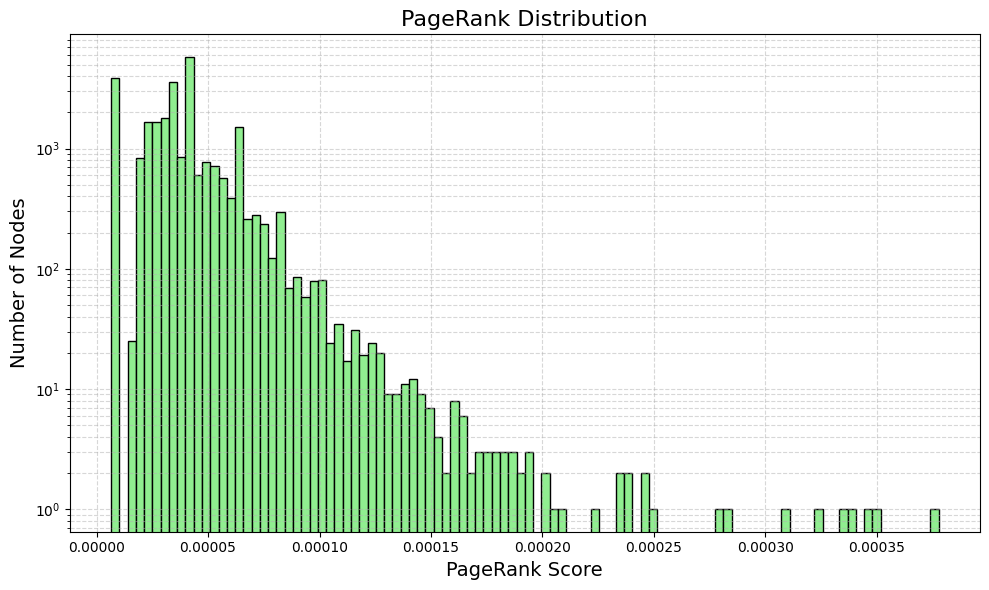

In [ ]:
# Calcolo del PageRank per grafo diretto
pagerank_scores = g.pagerank(directed=True)

# Visualizzazione distribuzione PageRank
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(pagerank_scores, bins=100, color='lightgreen', edgecolor='black')
plt.title("PageRank Distribution", fontsize=16)
plt.xlabel("PageRank Score", fontsize=14)
plt.ylabel("Number of Nodes", fontsize=14)
plt.yscale('log')  # scala logaritmica per evidenziare la distribuzione spesso molto sbilanciata
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
top_n = 10
top_nodes = sorted(zip(g.vs["name"], pagerank_scores), key=lambda x: x[1], reverse=True)[:top_n]

for pid, score in top_nodes:
    title = g.vs.find(name=pid)["title"] if "title" in g.vs.attributes() else "N/A"
    print(f"ID: {pid} | Title: {title} | PageRank: {score:.6f}")


ID: B00LQZB9F8 | Title: GardenMate 100 Picchetti Ancore a Terra 150mm Ø 2,9mm di Filo di Acciaio per Telo Pacciamatura | PageRank: 0.000378
ID: B0792HCFTG | Title: Echo Dot (3ª generazione) - Altoparlante intelligente con integrazione Alexa - Tessuto antracite | PageRank: 0.000349
ID: B0002M6CVC | Title: Cordes pour guitare électrique Ernie Ball Regular Slinky Nound - Calibre 10-46 | PageRank: 0.000346
ID: B000BNSYHW | Title: D'Addario PW-LMN Detergente Planet Waves Lemon Oil | PageRank: 0.000340
ID: B00UFGMVFG | Title: Bruzzzler 200100001066, Ciminiera con impugnatura di sicurezza - accenditore, 31 x 19,5 x 30,5 cm | PageRank: 0.000334
ID: B01LJKXIXU | Title: Caffè Borbone - 50 Capsule Don Carlo Compatibili Lavazza A Modo Mio Espresso - Miscela DEK | PageRank: 0.000324
ID: B06X6MV6WP | Title: Zacro Kit Accessori di Riparazione Orologio, Strumento Regolazione Cinturino Orologi Link Remover Professionale con 8 Pinzette | PageRank: 0.000309
ID: B00ZA6URIY | Title: Wpro SKS101 Kit di acca

###Intra topology in our products
Now we will do a betweenness analysis in intra-topology and inter-topology, to see which products act as bridges and connections.

In [ ]:
category_to_nodes = defaultdict(list)
for v in g.vs:
    cat = v["category"]
    if cat:
        category_to_nodes[cat].append(v.index)


category_stats = {}

for cat, indices in category_to_nodes.items():
    subg = g.subgraph(indices)
    deg = subg.degree()
    betw = subg.betweenness()
    page = subg.pagerank()

    category_stats[cat] = {
        "mean_degree": np.mean(deg),
        "max_degree": np.max(deg),
        "top_degree": subg.vs[np.argmax(deg)]["title"],

        "mean_betweenness": np.mean(betw),
        "max_betweenness": np.max(betw),
        "top_betweenness": subg.vs[np.argmax(betw)]["title"],

        "mean_pagerank": np.mean(page),
        "max_pagerank": np.max(page),
        "top_pagerank": subg.vs[np.argmax(page)]["title"]
    }


In this graph, we can observe that many nodes exhibit very high betweenness centrality, highlighting markets characterized by a strong clustering of objects.

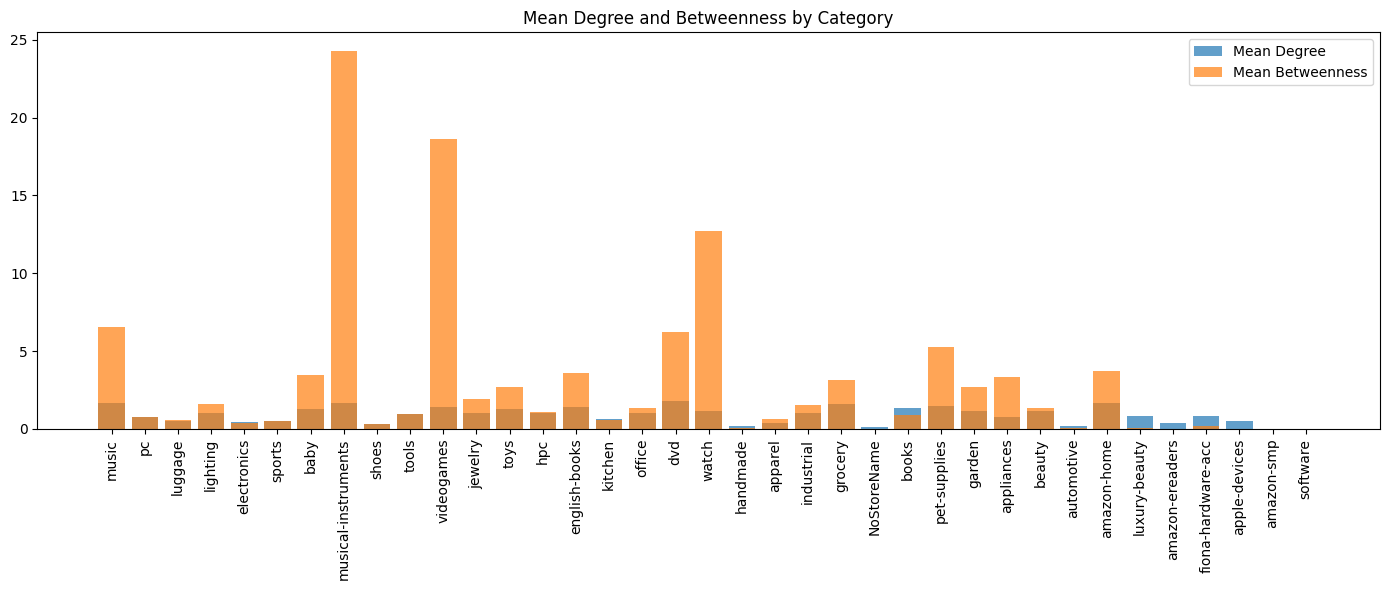

In [ ]:
categories = list(category_stats.keys())
mean_degrees = [category_stats[cat]["mean_degree"] for cat in categories]
mean_betw = [category_stats[cat]["mean_betweenness"] for cat in categories]

plt.figure(figsize=(14,6))
plt.bar(categories, mean_degrees, alpha=0.7, label='Mean Degree')
plt.bar(categories, mean_betw, alpha=0.7, label='Mean Betweenness')
plt.xticks(rotation=90)
plt.legend()
plt.title("Mean Degree and Betweenness by Category")
plt.tight_layout()
plt.show()

Mentre in questo caso i top prodotti per categoria che vengono acquistati insieme a qualcosa con le relative metriche betweness, pageRank, e degree.

In [ ]:
for cat, stat in category_stats.items():
    print(f"Category: {cat}")
    print(f"  Top Degree: {stat['top_degree']}")
    print(f"  Top Betweenness: {stat['top_betweenness']}")
    print(f"  Top PageRank: {stat['top_pagerank']}\n")

Category: music
  Top Degree: Start
  Top Betweenness: Dark Side of the Moon (180 gr)
  Top PageRank: Start

Category: pc
  Top Degree: Corsair Vengeance LPX Memorie per Desktop a Elevate Prestazioni, 16 GB (2 X 8 GB), DDR4, 3000 MHz, C15 XMP 2.0, Nero
  Top Betweenness: Corsair Vengeance LPX Memorie per Desktop a Elevate Prestazioni, 16 GB (2 X 8 GB), DDR4, 3000 MHz, C15 XMP 2.0, Nero
  Top PageRank: Corsair Vengeance LPX Memorie per Desktop a Elevate Prestazioni, 16 GB (2 X 8 GB), DDR4, 3000 MHz, C15 XMP 2.0, Nero

Category: luggage
  Top Degree: Carta di blocco RFID / NFC Protezione per carta di credito contactless, carte bancaria, pasaporto, carta bancomat - Protegge l'intero portafoglio - Sostituisce le custodie di blocco per porta-carte.
  Top Betweenness: Carta di blocco RFID / NFC Protezione per carta di credito contactless, carte bancaria, pasaporto, carta bancomat - Protegge l'intero portafoglio - Sostituisce le custodie di blocco per porta-carte.
  Top PageRank: Carta di blo

###Inter topology in our products
We will now examine which products serve as bridges between different categories, creating connections to other items. This analysis can be particularly useful for understanding how to enter a specific market or to identify which types of products are likely to be sought after by consumers following the purchase of a primary item.



As we can see from the data, several products appear to be misclassified—for example, bracelets listed under the kitchen category. Nevertheless, with the current code, we are able to visualize all relevant relationships, highlighting the most significant edges where products connect across different categories.

In [ ]:
# Compute edge betweenness centrality for all edges
edge_betw = g.edge_betweenness()
g.es["edge_betweenness"] = edge_betw

# Minimum threshold for edge betweenness to consider a bridge edge
min_edge_betweenness = np.percentile(bet, 97)

# Identify edges that connect nodes from **different categories**
bridge_edges = []
for e in g.es:
    src_idx = e.source
    tgt_idx = e.target

    src_cat = g.vs[src_idx]["category"]
    tgt_cat = g.vs[tgt_idx]["category"]

    if src_cat and tgt_cat and src_cat != tgt_cat:
        score = e["edge_betweenness"]
        if score >= min_edge_betweenness:
            bridge_edges.append({
                "source_id": g.vs[src_idx]["name"],
                "target_id": g.vs[tgt_idx]["name"],
                "source_title": g.vs[src_idx]["title"],
                "target_title": g.vs[tgt_idx]["title"],
                "source_cat": src_cat,
                "target_cat": tgt_cat,
                "edge_betweenness": score
            })

# Sort bridge edges by descending edge betweenness
bridge_edges = sorted(bridge_edges, key=lambda x: x["edge_betweenness"], reverse=True)

# Print the top 15 bridging edges between different categories, including IDs
for be in bridge_edges[:15]:
    print(f"{be['source_title']} ({be['source_cat']}) [ID: {be['source_id']}]")
    print(f"↔")
    print(f"{be['target_title']} ({be['target_cat']}) [ID: {be['target_id']}]")
    print(f"Edge Betweenness: {be['edge_betweenness']:.2f}")
    print("-" * 100)

Mcitymall77 Collana d'Argento 925, da Donna, Ottima qualità (A) (kitchen) [ID: B00HD49OH6]
↔
Hilai donne zircone fiore lungo regolabile catena pendente della collana del maglione (jewelry) [ID: B07D499LSQ]
Edge Betweenness: 636.00
----------------------------------------------------------------------------------------------------
Hilai donne zircone fiore lungo regolabile catena pendente della collana del maglione (jewelry) [ID: B07D499LSQ]
↔
Binmer (TM) Collana con ciondolo da donna e ragazza, motivo con perla e foglie (kitchen) [ID: B00WJB31DG]
Edge Betweenness: 594.00
----------------------------------------------------------------------------------------------------
Fablcrew - Braccialetto da donna, alla moda, design con catenina in argento e perle effetto sabbiato, ideale come regalo (kitchen) [ID: B076D78225]
↔
Epoch World Bracciale Tennis in Argento Oro Bianco con Zirconi Bianchi braccialetto di tennis eleganza moderna (sports) [ID: B07CJLMQQ6]
Edge Betweenness: 550.00
---------

### Clustering
In this case, a clustering approach will be applied to group products into more coherent categories—such as electronics, video games, etc.—in order to identify products that are truly similar to one another. This segmentation allows for a more meaningful interpretation of the network.

Previously, some clusters (e.g., jewelry products) were connected to completely unrelated items such as kitchenware. As a result, computing betweenness centrality across the entire graph introduced noise and produced misleading results that did not reflect actual market relationships.

By analyzing each cluster independently, we can better understand the internal structure of specific product segments and identify key or bridge products within a relevant and semantically consistent context. This leads to more accurate and insightful outcomes when analyzing influence, centrality, and potential recommendation strategies.

This approach aims to refine the network representation by consolidating misclassified or loosely linked items into more coherent groups. The goal is not to over-segment the data but rather to improve the semantic quality of the clusters—especially in cases where product connections do not reflect real-world relationships (e.g., jewelry items linked to kitchen appliances).

By doing this, we can assess whether such regrouping brings measurable benefits to the network's interpretability and analytical value, particularly in centrality-based analysis and product recommendation scenarios.

In [ ]:
# Count the number of unique categories in the graph
categories = set(v["category"] for v in g.vs if v["category"])
num_categories = len(categories)

print(f"Numero di categorie uniche nel grafo: {num_categories}")

Numero di categorie uniche nel grafo: 37


In [ ]:
if g.is_directed():
    g.to_undirected(inplace=True)
    print("Approve")

louvain_clusters = g.community_multilevel()

graph_louvain = g
# Salva l'indice del cluster per ogni nodo
graph_louvain.vs["louvain_cluster"] = louvain_clusters.membership

# Quanti cluster ha trovato?
print(f"Numero di cluster rilevati: {len(louvain_clusters)}, modularity: {louvain_clusters.modularity}")

# Esempio: stampa primi 10 nodi con titolo, categoria originale e cluster Louvain
for v in g.vs[:10]:
    print(f"Titolo: {v['title']}, Categoria: {v['category']}, Cluster: {v['louvain_cluster']}")

Numero di cluster rilevati: 9249, modularity: 0.9994019915722561
Titolo: I RAGAZZI STANNO BENE 1994, Categoria: music, Cluster: 0
Titolo: AmazonBasics - Cavo patch Ethernet di Cat6 con connettori RJ45, 1,5 m - Pacco da 5, Categoria: pc, Cluster: 1
Titolo: LOSMILE Uomo Tela Borsa a Tracolla Borsa di Tela Sacchetto del Messaggero Sacchetto di Messenger bag 16 pollici Laptop Borsa. (Caffè), Categoria: luggage, Cluster: 2
Titolo: Luce per lettura, DELBOZ, lampada led, 2 livelli luminosità regolabili, 4 LED, luce notturna, luce lettura, ricarica USB, lampada clip, luce da lettura, luce libro, kindle, letto, viaggio[classe A++], Categoria: lighting, Cluster: 3
Titolo: 100% ORIGINAL - Confenzione 5 Pz. AUTHENTIC Justfog Resistenza 1.6 ohm per JUSTFOG Q16 / Q14 / C14 / G14 / S14 / P16A / P14A Resistenze - Codice di sicurezza verificabile sul sito JUSTFOG, Categoria: electronics, Cluster: 4
Titolo: None, Categoria: None, Cluster: 5
Titolo: Borsa Bici Telaio DeFe Borse Bicicletta Manubrio Imperm

#### Pre-Processing

In [ ]:
min_nodes = 10  # Threshold for keeping meaningful components
components = g.connected_components()

# Keep only components with sufficient size
filtered_subgraphs = [comp for comp in components.subgraphs() if comp.vcount() >= min_nodes]

# Start with the first subgraph
g_filtered = filtered_subgraphs[0]

# Iteratively union the others
for sg in filtered_subgraphs[1:]:
    g_filtered = g_filtered.disjoint_union(sg)

print(f"Filtered graph has {g_filtered.vcount()} nodes and {g_filtered.ecount()} edges")

Filtered graph has 5390 nodes and 6677 edges


In [ ]:
for v in g_filtered.vs[:5]:
    print(f"Index {v.index} → {v.attributes()}")

Index 0 → {'name': 'B07MWYQDNC', 'title': 'I RAGAZZI STANNO BENE 1994', 'category': 'music', 'price': {'$numberDouble': '17.95'}, 'avg_rating': {'$numberDouble': '4.4'}, 'reviews_number': {'$numberInt': '22'}, 'questions_number': {'$numberInt': '0'}, 'versions': [], 'review_rating_score': 0.36029338343155676, 'louvain_cluster': 0}
Index 1 → {'name': 'B07MXNZVY5', 'title': 'Start', 'category': 'music', 'price': {'$numberDouble': '17.89'}, 'avg_rating': {'$numberDouble': '4.7'}, 'reviews_number': {'$numberInt': '130'}, 'questions_number': {'$numberInt': '0'}, 'versions': [], 'review_rating_score': 0.3902308464369354, 'louvain_cluster': 0}
Index 2 → {'name': 'B07NB94622', 'title': "L'Altra Meta'", 'category': 'music', 'price': {'$numberDouble': '17.76'}, 'avg_rating': None, 'reviews_number': {'$numberInt': '0'}, 'questions_number': {'$numberInt': '0'}, 'versions': [], 'review_rating_score': 0.0, 'louvain_cluster': 0}
Index 3 → {'name': 'B003GXZL8E', 'title': 'Arrivederci, Mostro!', 'categ

#### Community Detection

In [ ]:
# Using Louvain as default
g_filtered.vs["community"] = g_filtered.community_multilevel().membership

# Count clusters and compute modularity
num_clusters = len(set(g_filtered.vs["community"]))
modularity_score = g_filtered.modularity(g_filtered.vs["community"])
print(f"Detected {num_clusters} clusters with modularity score: {modularity_score:.4f}")

Detected 332 clusters with modularity score: 0.9957


In [ ]:
for v in g_filtered.vs[:5]:
    print(f"Index {v.index} → {v.attributes()}")

Index 0 → {'name': 'B07MWYQDNC', 'title': 'I RAGAZZI STANNO BENE 1994', 'category': 'music', 'price': {'$numberDouble': '17.95'}, 'avg_rating': {'$numberDouble': '4.4'}, 'reviews_number': {'$numberInt': '22'}, 'questions_number': {'$numberInt': '0'}, 'versions': [], 'review_rating_score': 0.36029338343155676, 'louvain_cluster': 0, 'community': 0}
Index 1 → {'name': 'B07MXNZVY5', 'title': 'Start', 'category': 'music', 'price': {'$numberDouble': '17.89'}, 'avg_rating': {'$numberDouble': '4.7'}, 'reviews_number': {'$numberInt': '130'}, 'questions_number': {'$numberInt': '0'}, 'versions': [], 'review_rating_score': 0.3902308464369354, 'louvain_cluster': 0, 'community': 0}
Index 2 → {'name': 'B07NB94622', 'title': "L'Altra Meta'", 'category': 'music', 'price': {'$numberDouble': '17.76'}, 'avg_rating': None, 'reviews_number': {'$numberInt': '0'}, 'questions_number': {'$numberInt': '0'}, 'versions': [], 'review_rating_score': 0.0, 'louvain_cluster': 0, 'community': 0}
Index 3 → {'name': 'B003

In [ ]:
unique_categories = Counter(g.vs['category'])
print(unique_categories)

unique_categories = Counter(g_filtered.vs['category'])
print(unique_categories)

unique_community = Counter(g_filtered.vs['community'])
print(unique_community)

Counter({None: 6080, 'kitchen': 1784, 'electronics': 1143, 'tools': 1125, 'books': 993, 'apparel': 946, 'sports': 887, 'english-books': 873, 'jewelry': 846, 'hpc': 839, 'toys': 800, 'baby': 734, 'garden': 697, 'music': 672, 'shoes': 653, 'luggage': 638, 'beauty': 617, 'dvd': 616, 'musical-instruments': 601, 'lighting': 569, 'watch': 563, 'videogames': 558, 'office': 512, 'pc': 508, 'grocery': 488, 'pet-supplies': 456, 'appliances': 418, 'handmade': 392, 'industrial': 381, 'automotive': 72, 'luxury-beauty': 30, 'NoStoreName': 20, 'amazon-home': 12, 'amazon-ereaders': 5, 'fiona-hardware-acc': 5, 'apple-devices': 4, 'amazon-smp': 1, 'software': 1})
Counter({None: 599, 'kitchen': 356, 'musical-instruments': 297, 'tools': 266, 'garden': 266, 'baby': 237, 'videogames': 218, 'watch': 210, 'jewelry': 207, 'dvd': 199, 'hpc': 193, 'pet-supplies': 181, 'english-books': 181, 'apparel': 175, 'music': 162, 'office': 157, 'electronics': 157, 'industrial': 146, 'beauty': 146, 'lighting': 141, 'toys': 

#### Interpretation: Label each cluster by dominant category or theme
Thanks to this, we could go and show sub-portions of graphs related to the category we want to study, and in case, find the best product for that specific type. In the case of understanding which cluster it belongs to, we can conduct a search based on the title and understand to which part the product belongs.

In [ ]:
cluster_labels = {}
for cluster_id in range(num_clusters):
    nodes_in_cluster = g_filtered.vs.select(community=cluster_id)
    categories = nodes_in_cluster["category"]

    if categories:
        # Count all the categories
        category_counts = Counter(categories)
        # Categories most common
        most_common_cat, most_common_count = category_counts.most_common(1)[0]
        # Generate a string with all categories and their respective frequencies
        all_categories_str = ", ".join([f"{cat} ({count})" for cat, count in category_counts.items()])
        # Combine the dominant category with the complete list.
        label_str = f"| Dominant: {most_common_cat} ({most_common_count}) -> All: {all_categories_str}"
    else:
        label_str = "Unknown"

    cluster_labels[cluster_id] = label_str

print("\nCluster interpretation (all categories with counts and dominant category):")
for cid, label in cluster_labels.items():
    print(f"Cluster {cid}: {label}")



Cluster interpretation (all categories with counts and dominant category):
Cluster 0: | Dominant: music (17) -> All: music (17), None (1)
Cluster 1: | Dominant: tools (7) -> All: tools (7), None (2), industrial (2), kitchen (1)
Cluster 2: | Dominant: videogames (14) -> All: videogames (14)
Cluster 3: | Dominant: jewelry (7) -> All: jewelry (7), kitchen (1), None (1), sports (1)
Cluster 4: | Dominant: baby (9) -> All: baby (9), None (1)
Cluster 5: | Dominant: office (6) -> All: office (6), pc (4), electronics (2)
Cluster 6: | Dominant: dvd (23) -> All: dvd (23), books (1), None (1)
Cluster 7: | Dominant: watch (58) -> All: watch (58), None (9), shoes (1), electronics (3)
Cluster 8: | Dominant: musical-instruments (39) -> All: musical-instruments (39), sports (1), None (3), electronics (1), kitchen (1)
Cluster 9: | Dominant: musical-instruments (5) -> All: industrial (4), hpc (3), musical-instruments (5), None (1)
Cluster 10: | Dominant: garden (13) -> All: kitchen (3), garden (13), too

An example

Cluster 5 subgraph:
Number of nodes: 12
Number of edges: 16


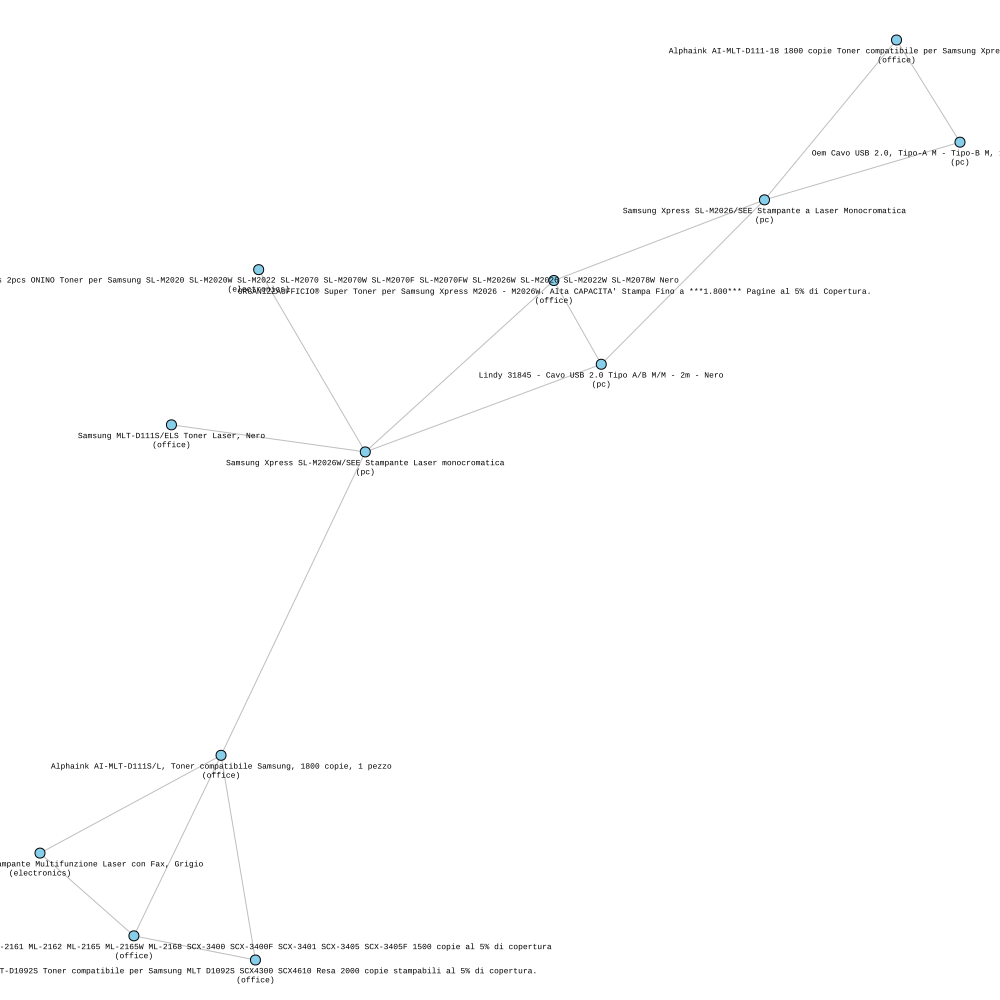

In [ ]:
# Look one sample
cluster_id = 5
subgraph = g_filtered.subgraph(g_filtered.vs.select(community=cluster_id))

print(f"Cluster {cluster_id} subgraph:")
print(f"Number of nodes: {subgraph.vcount()}")
print(f"Number of edges: {subgraph.ecount()}")

layout = subgraph.layout("fr")  # Layout Force-directed

# Create labe combine category and title
labels = []
for v in subgraph.vs:
    name = v["title"] if "title" in v.attributes() else "N/A"
    category = v["category"] if "category" in v.attributes() else "N/A"
    labels.append(f"{name}\n({category})")

ig.plot(
    subgraph,
    layout=layout,
    vertex_label=labels,
    vertex_size=10,
    bbox=(1000, 1000),
    margin=40,
    vertex_color="skyblue",
    edge_color="gray",
    vertex_label_size=8,
    vertex_label_dist=1.5
)


We can see the best categories in our graph. Initially, we noticed that some product categories might have been misclassified, which could lead to misleading inter/intra-cluster relationships due to an incorrect topology. Therefore, I explored an approach based on clustering. However, even if a cluster contains only 5 products — for instance, 3 kitchen and 2 toys — this doesn't necessarily mean the cluster is misclassified or should be labeled solely as 'kitchen'. As a result, I decided not to enforce strict labeling rules. Instead, I will conduct a more nuanced analysis focused on identifying the best-performing products within each cluster and examining inter-cluster dynamics

In [ ]:
all_categories = [v["category"] for v in g.vs if v["category"] is not None]
category_counts = Counter(all_categories)

print(f"Unique categories: {len(category_counts)}")
print("Top categories:")
for cat, count in category_counts.most_common(37):
    print(f"{cat}: {count} nodi")

Unique categories: 37
Top categories:
kitchen: 1784 nodi
electronics: 1143 nodi
tools: 1125 nodi
books: 993 nodi
apparel: 946 nodi
sports: 887 nodi
english-books: 873 nodi
jewelry: 846 nodi
hpc: 839 nodi
toys: 800 nodi
baby: 734 nodi
garden: 697 nodi
music: 672 nodi
shoes: 653 nodi
luggage: 638 nodi
beauty: 617 nodi
dvd: 616 nodi
musical-instruments: 601 nodi
lighting: 569 nodi
watch: 563 nodi
videogames: 558 nodi
office: 512 nodi
pc: 508 nodi
grocery: 488 nodi
pet-supplies: 456 nodi
appliances: 418 nodi
handmade: 392 nodi
industrial: 381 nodi
automotive: 72 nodi
luxury-beauty: 30 nodi
NoStoreName: 20 nodi
amazon-home: 12 nodi
amazon-ereaders: 5 nodi
fiona-hardware-acc: 5 nodi
apple-devices: 4 nodi
amazon-smp: 1 nodi
software: 1 nodi


#### Actionable Insights
Intra and inter clusters betwenness, to find the best products for each cluster and the best products to connect different clusters.

This graph is identical to the one from the betweenness analysis because the nodes remain the same; no nodes were removed due to being too small.

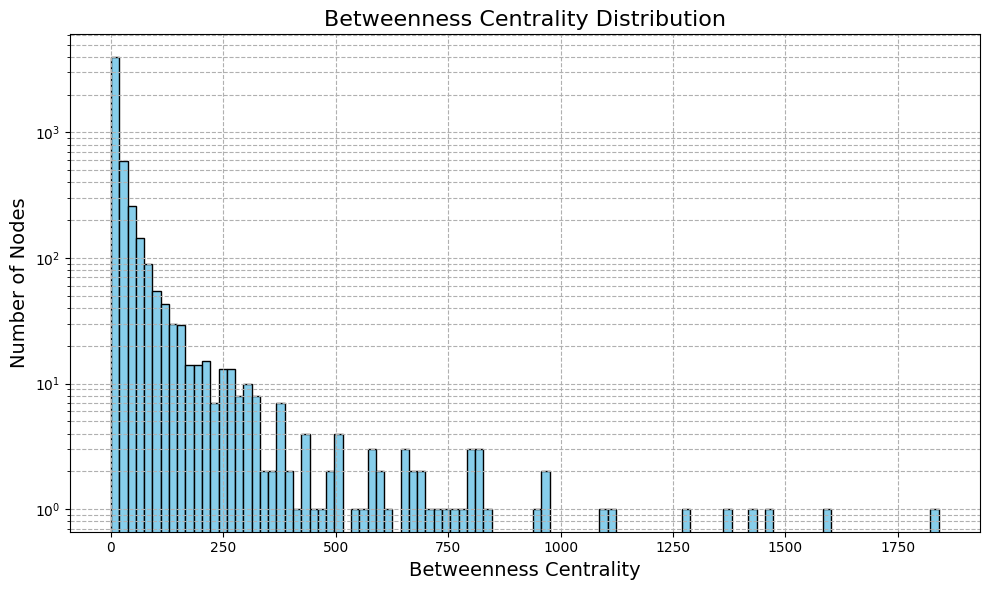

In [ ]:
bet = g_filtered.betweenness()

plt.figure(figsize=(10, 6))
plt.hist(bet, bins=100, color='skyblue', edgecolor='black')
plt.title('Betweenness Centrality Distribution', fontsize=16)
plt.xlabel('Betweenness Centrality', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.yscale('log')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [ ]:
# Identify "bridge nodes" = high betweenness
g_filtered.vs["betweenness_cluster"] = bet
threshold = np.percentile(bet, 97)
bridge_nodes = g_filtered.vs.select(lambda v: v["betweenness_cluster"] >= threshold)

print(f"\nTop bridge nodes (potential cross-segment promoters):")
for node in bridge_nodes:
    print(f"ID: {node['name']} | Category: {node['category']} | Community:{node['community']} |Betweenness: {node['betweenness_cluster']:.2f}")

# Example: identify underrepresented clusters
min_cluster_size = 10
print("\nUnderrepresented clusters (small but valid):")
for cid in range(num_clusters):
    cluster_nodes = g_filtered.vs.select(community=cid)
    if len(cluster_nodes) <= min_cluster_size:
        print(f"Cluster {cid} (size={len(cluster_nodes)}): Dominant category → {cluster_labels[cid]}")


Top bridge nodes (potential cross-segment promoters):
ID: B07885BXMV | Category: watch | Community:7 |Betweenness: 825.00
ID: B01NBU5UK9 | Category: watch | Community:7 |Betweenness: 1104.50
ID: B00DSYVL7Q | Category: watch | Community:7 |Betweenness: 798.50
ID: B004KPKUBU | Category: watch | Community:7 |Betweenness: 1376.00
ID: B008PDQT6I | Category: watch | Community:7 |Betweenness: 497.00
ID: B07B82PH74 | Category: watch | Community:7 |Betweenness: 201.00
ID: B0788LYKQ6 | Category: watch | Community:7 |Betweenness: 790.00
ID: B000GAYQJ0 | Category: watch | Community:7 |Betweenness: 203.00
ID: B0078XYT6I | Category: watch | Community:7 |Betweenness: 270.00
ID: B002LAS086 | Category: watch | Community:7 |Betweenness: 267.00
ID: B07GT76D3G | Category: watch | Community:7 |Betweenness: 264.00
ID: B07GT4QMJS | Category: watch | Community:7 |Betweenness: 224.00
ID: B0788CGDMF | Category: watch | Community:7 |Betweenness: 267.00
ID: B01KV87YZ4 | Category: watch | Community:7 |Betweenness

Let’s examine the distribution of the top 20 clusters. As shown in the graph, some clusters exhibit a high degree of heterogeneity.

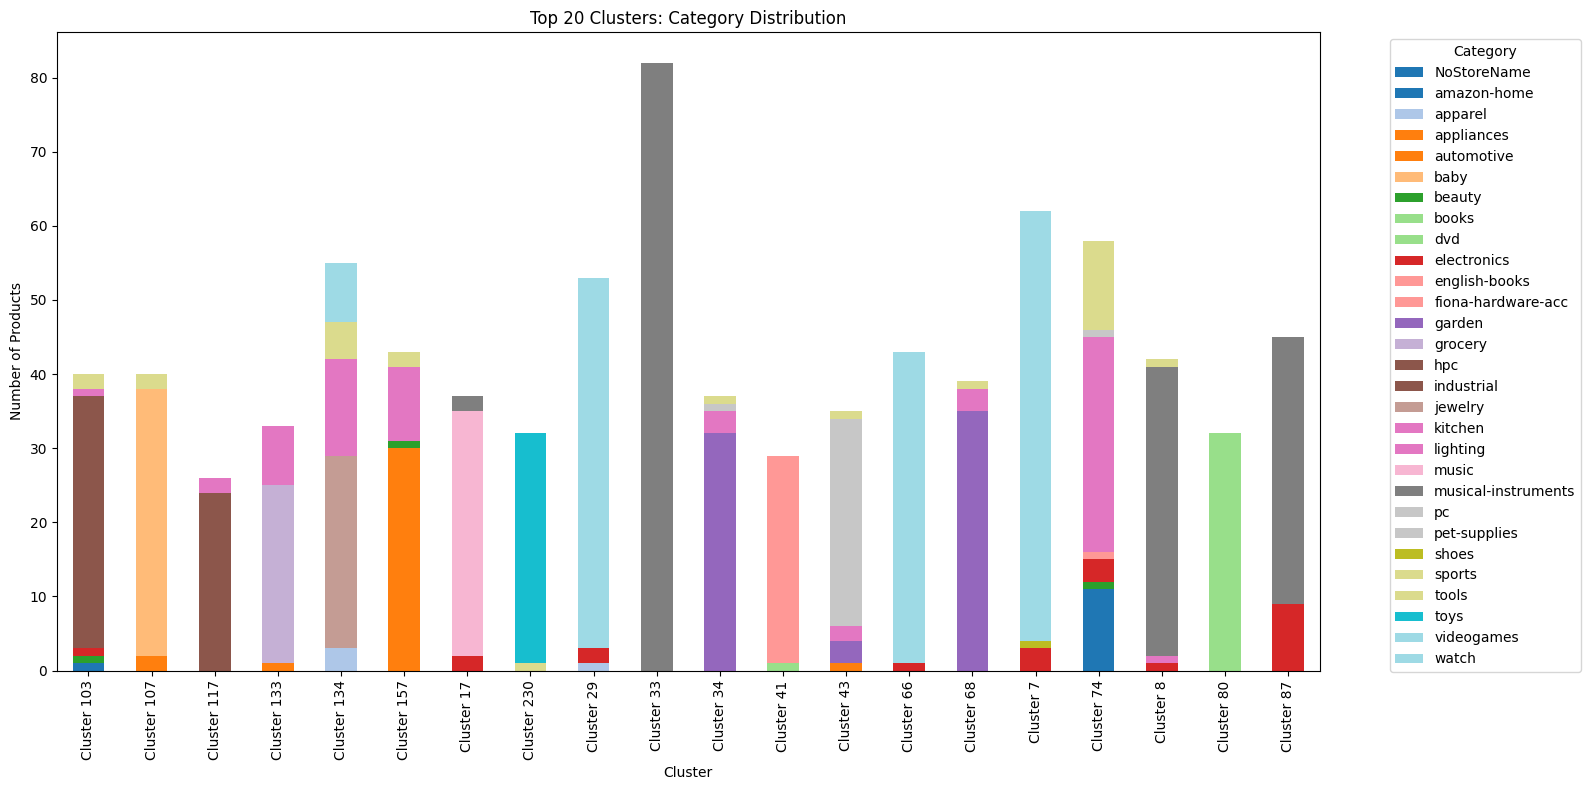

In [ ]:
cluster_sizes = {cid: len(g_filtered.vs.select(community=cid)) for cid in range(num_clusters)}

top_n = 20
top_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_cluster_ids = [cid for cid, _ in top_clusters]

data = []

for cluster_id in top_cluster_ids:
    nodes = g_filtered.vs.select(community=cluster_id)
    cat_counts = Counter(nodes["category"])
    for cat, count in cat_counts.items():
        if cat:  # escludi None
            data.append({"Cluster": f"Cluster {cluster_id}", "Category": cat, "Count": count})

df = pd.DataFrame(data)

pivot_df = df.pivot_table(index="Cluster", columns="Category", values="Count", fill_value=0)

pivot_df.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='tab20')
plt.title(f"Top {top_n} Clusters: Category Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Category')
plt.tight_layout()
plt.show()


Cluster 106 subgraph:
Number of nodes: 10
Number of edges: 13


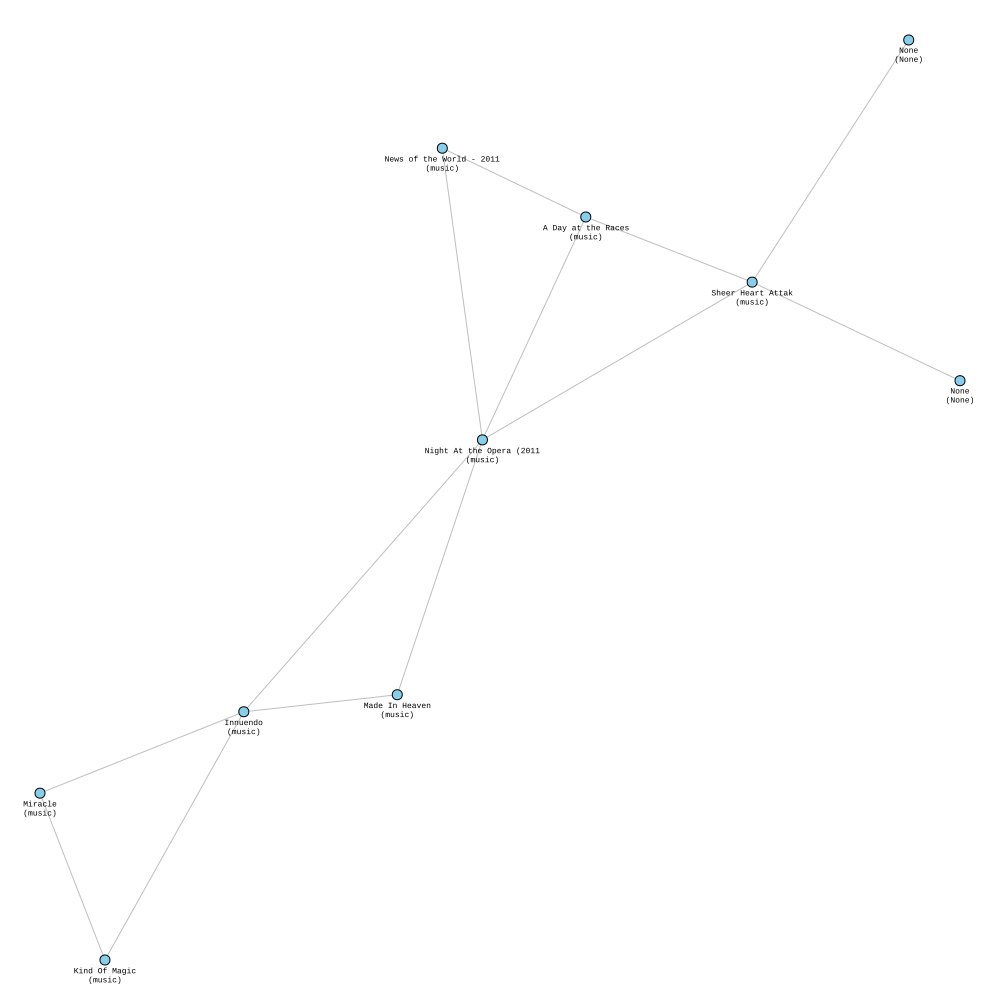

In [ ]:
# Look one sample
cluster_id = 106
subgraph = g_filtered.subgraph(g_filtered.vs.select(community=cluster_id))

print(f"Cluster {cluster_id} subgraph:")
print(f"Number of nodes: {subgraph.vcount()}")
print(f"Number of edges: {subgraph.ecount()}")

layout = subgraph.layout("fr")  # Layout Force-directed

# Create labe combine category and title
labels = []
for v in subgraph.vs:
    name = v["title"] if "title" in v.attributes() else "N/A"
    category = v["category"] if "category" in v.attributes() else "N/A"
    labels.append(f"{name}\n({category})")

ig.plot(
    subgraph,
    layout=layout,
    vertex_label=labels,
    vertex_size=10,
    bbox=(1000, 1000),
    margin=40,
    vertex_color="skyblue",
    edge_color="gray",
    vertex_label_size=8,
    vertex_label_dist=1.5
)


Another thing we could do might be to take the individual clusters and perform analysis for all 331 clusters found by identifying the best products based on betweenness and degree.

In [ ]:
# Compute the centrality
if "betweenness" not in g_filtered.vs.attributes():
    betweenness = g_filtered.betweenness()
    g_filtered.vs["betweenness"] = betweenness

if "degree" not in g_filtered.vs.attributes():
    degree = g_filtered.degree()
    g_filtered.vs["degree"] = degree

num_clusters = len(set(g_filtered.vs["community"]))

# Treshold changable
betw_threshold_percentile = 90
degree_threshold_percentile = 90

print(f"Analyzing {num_clusters} clusters for top products by betweenness and degree...\n")

for cluster_id in range(num_clusters):
    nodes_in_cluster = g_filtered.vs.select(community=cluster_id)

    betw_values = nodes_in_cluster["betweenness"]
    degree_values = nodes_in_cluster["degree"]

    # Calcola soglie per il cluster attuale
    betw_threshold = np.percentile(betw_values, betw_threshold_percentile)
    degree_threshold = np.percentile(degree_values, degree_threshold_percentile)

    # Seleziona nodi sopra soglia
    top_betw_nodes = [v for v in nodes_in_cluster if v["betweenness"] >= betw_threshold]
    top_degree_nodes = [v for v in nodes_in_cluster if v["degree"] >= degree_threshold]

    print(f"Cluster {cluster_id}:")
    print(f" Top Betweenness threshold ({betw_threshold_percentile} percentile): {betw_threshold:.4f}")
    print(f" Top Degree threshold ({degree_threshold_percentile} percentile): {degree_threshold:.4f}")
    print(f" Nodes with top betweenness: {len(top_betw_nodes)}")
    for node in top_betw_nodes:
        print(f"  - {node['name']} | Betweenness: {node['betweenness']:.4f} | Degree: {node['degree']} | Category: {node['category']}")

    print(f" Nodes with top degree: {len(top_degree_nodes)}")
    for node in top_degree_nodes:
        print(f"  - {node['name']} | Degree: {node['degree']} | Betweenness: {node['betweenness']:.4f} | Category: {node['category']}")

    print("\n" + "-"*40 + "\n")


Analyzing 332 clusters for top products by betweenness and degree...

Cluster 0:
 Top Betweenness threshold (90 percentile): 28.6000
 Top Degree threshold (90 percentile): 4.3000
 Nodes with top betweenness: 2
  - B07MXNZVY5 | Betweenness: 118.0000 | Degree: 11 | Category: music
  - B07P61PWXP | Betweenness: 30.0000 | Degree: 3 | Category: music
 Nodes with top degree: 2
  - B07MXNZVY5 | Degree: 11 | Betweenness: 118.0000 | Category: music
  - B00G6DDBI8 | Degree: 5 | Betweenness: 28.0000 | Category: music

----------------------------------------

Cluster 1:
 Top Betweenness threshold (90 percentile): 27.8000
 Top Degree threshold (90 percentile): 3.9000
 Nodes with top betweenness: 2
  - B008BGYDBC | Betweenness: 28.0000 | Degree: 3 | Category: industrial
  - B01I3IMSSM | Betweenness: 28.0000 | Degree: 4 | Category: tools
 Nodes with top degree: 2
  - B0099TJARM | Degree: 4 | Betweenness: 19.0000 | Category: kitchen
  - B01I3IMSSM | Degree: 4 | Betweenness: 28.0000 | Category: tools


As we can see from this code, the luovain clusters cause the graph to create isolated subgroups from one another, resulting in 0 inter-cluster edge numbers.

In [ ]:
inter_cluster_edges = []
inter_cluster_indices = []

for idx, e in enumerate(g_filtered.es):
    src = g_filtered.vs[e.source]
    tgt = g_filtered.vs[e.target]
    if src["community"] != tgt["community"]:
        inter_cluster_edges.append(e)
        inter_cluster_indices.append(idx)

print(f"Numero di archi inter-cluster: {len(inter_cluster_edges)}")

Numero di archi inter-cluster: 0


This comprehensive analysis provided a multi-level understanding of the product co-purchase network. Starting from identifying key products by centrality, we uncovered the community structure using Louvain clustering, and differentiated between intra-cluster cohesion and inter-cluster bridging products via edge betweenness. These insights facilitate targeted marketing, recommendation strategies, and potential product bundling, grounded on the topology and category distribution of the network.

## Join of new Relations
By using the 'also_bought' relationship, we can find those products that the user initially felt they did not need to purchase, but that could be useful to buy at some point in the future due to certain events.

By using 'also_viewed' we can usually find those products in the niche of a certain person

### Also_bought of new Relations

As we can see from the json file the Id in "Bought_togheter" is present in also_bought. Make it sure with a cycle.

In [ ]:
target_id = 'B016DNCWHG'
print_product_by_id(target_id, json_file_products)

{
  "_id": "B016DNCWHG",
  "title": "Kingdom Hearts HD 2.8 Final Chapter: Prologue - PlayStation 4",
  "category": "videogames",
  "price": {
    "$numberDouble": "28.18"
  },
  "avg_rating": {
    "$numberDouble": "4.5"
  },
  "reviews_number": {
    "$numberInt": "160"
  },
  "questions_number": {
    "$numberInt": "68"
  },
  "pictures": [
    "https://images-na.ssl-images-amazon.com/images/I/81ytdxDunSL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/81xPO8XT9KL.jpg"
  ],
  "description": "Descrizione prodotto\nUna raccolta unica\nKingdom Hearts HD 2.8 Final Chapter Prologue è una raccolta rimasterizzata, per la prima volta in su Playstation 4, che include: la versione rimasterizzata in alta definizione di Kingdom Hearts [Dream Drop Distance] HD, Kingdom Hearts 0.2 Birth by Sleep: A Fragmentary Passage e Kingdom Hearts x [chi] Back Cover (movie).\n\"La paura è l'oscura prigione della luce. Il coraggio è la chiave\"\nKingdom Hearts HD 2.8 Final Chapter Prologue\nKINGDOM 

In [ ]:
json_file_products[1]

{'_id': 'B07NVMYB7K',
 'title': 'Sega Megadrive Mini',
 'category': 'videogames',
 'price': {'$numberDouble': '79.99'},
 'avg_rating': None,
 'reviews_number': {'$numberInt': '0'},
 'questions_number': {'$numberInt': '0'},
 'pictures': ['https://images-na.ssl-images-amazon.com/images/I/711Wxi%2BAQcL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/81YvgbmVRNL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/81xogKmANSL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/719zwpydeRL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/61K40QcRPrL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/71vCfEiatEL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/81lbtLkYEAL.jpg'],
 'description': '',
 'features': ["L'iconica console di SEGA, il 55% più piccola",
  'Include 40 giochi tra i più iconici mai rilasciati'],
 'versions': [],
 'bought_together': ['B07Q32Z74P'],
 'also_bought': ['B07PBKX3FG', 'B07Q32Z74P', 'B07Q82PCWX'],
 'also_viewed': ['B

What we can assume now is that not all products that are bought together are always purchased simultaneously. This means that some people find it useful to buy the product immediately along with the original item, while others neither buy it at the same time nor in the near future. If a product is frequently bought both together and separately, it suggests that the product is very useful, but users sometimes forget to purchase it along with the original item.

In [ ]:
found_inconsistency = False

for i in range(len(json_file_products)):
    product = json_file_products[i]

    bought_together = product.get('bought_together')
    also_bought = product.get('also_bought')

    # If 'bought_together' is None or empty, skip this product
    if not bought_together:
        continue

    # If 'also_bought' is None or empty, set it to empty list to avoid errors
    if not also_bought:
        also_bought = []

    # Check if every ID in 'bought_together' is present in 'also_bought'
    for bt_id in bought_together:
        if bt_id not in also_bought:
            print(f"Inconsistency found at index {i}: bought_together ID '{bt_id}' not in also_bought")
            # If you want to print only the first missing ID per product, you can add a break here
            found_inconsistency = True
            break

    # If we found an inconsistency, break out of the loop
    if found_inconsistency:
        break

Inconsistency found at index 2: bought_together ID 'B071GQXPTP' not in also_bought


We need to determine whether to use an undirected or directed graph by assessing if the relationships between nodes are mutual.

In [ ]:
json_file_products[42]

{'_id': 'B07BZV8R5R',
 'title': 'Super Smash Bros Ultimate - Nintendo Switch',
 'category': 'videogames',
 'price': {'$numberDouble': '54.99'},
 'avg_rating': {'$numberDouble': '4.8'},
 'reviews_number': {'$numberInt': '151'},
 'questions_number': {'$numberInt': '37'},
 'pictures': ['https://images-na.ssl-images-amazon.com/images/I/81Su3JGKtvL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/913LB6MsQEL.jpg'],
 'description': "Descrizione prodotto\nIl più grande crossover della storia dei videogiochi\nTutti i personaggi dei titoli precedenti si uniscono alla lotta, per un totale di 66 personaggi giocabili\nIl picchiaduro perfetto per tutti\nUn titolo ideale sia per i giocatori competitivi sia per chi vuole divertirsi con gli amici\nTantissimi scenari in cui lottare\nTornano gli scenari classici della saga in versione potenziata, insieme a tante arene\nIl Super Smash Bros. Più grande di sempre\nTra personaggi, arene, oggetti e modalità di gioco questo capitolo è davvero ricchis

In this example, we can observe that the product in also_bought 'B01M6ZGICT' is not bidirectional; in fact, in the also_bought list of the second product 'B01M6ZGICT', the ID of the first product is not present.

In [ ]:
target_id = 'B01M6ZGICT'
print_product_by_id(target_id, json_file_products)

{
  "_id": "B01M6ZGICT",
  "title": "Nintendo Switch",
  "category": "videogames",
  "price": {
    "$numberDouble": "298.89"
  },
  "avg_rating": {
    "$numberDouble": "4.5"
  },
  "reviews_number": {
    "$numberInt": "182"
  },
  "questions_number": {
    "$numberInt": "127"
  },
  "pictures": [
    "https://images-na.ssl-images-amazon.com/images/I/51WHmzu6eTL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/91NtdZ-26TL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/71c0RNZLlNL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/71brm7gg7cL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/61%2Ba1MDfOhL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/617cGLH%2B0BL.jpg",
    "https://images-na.ssl-images-amazon.com/images/I/71-6qnn%2BQ9L.jpg"
  ],
  "description": "Descrizione prodotto\nLa console da casa portatile\nNintendo Switch è una console casalinga rivoluzionaria che non solo si connette al televisore di casa, ma si trasfo

How many null valuies are there within the graph for the also bought relationship? And how many Values?

In [ ]:
found_inconsistency = False
nan_count = 0
not_nan_count = 0

for i in range(len(json_file_products)):
    product = json_file_products[i]

    also_bought = product.get('also_bought')

    # Conta NaN e non NaN per 'also_bought'
    if also_bought is None or len(also_bought) == 0:
        nan_count += 1
        if found_inconsistency == False:
            print(f"Inconsistency found at index {i}: also_bought is None or empty")
            found_inconsistency = True
        also_bought = []  # evita errori nel ciclo successivo
    else:
        not_nan_count += 1

print(f"Number of NaN values in 'also_bought': {nan_count}")
print(f"Number of non-NaN values in 'also_bought': {not_nan_count}")


Inconsistency found at index 98: also_bought is None or empty
Number of NaN values in 'also_bought': 819
Number of non-NaN values in 'also_bought': 19640


Now that we have examined the number of relationships, we can confidently proceed to make some inferences

In [ ]:
json_file_products[98]

{'_id': 'B01ETRGE7M',
 'title': 'Fire TV Stick | Basic Edition',
 'category': 'amazon-smp',
 'price': {'$numberDouble': '39.99'},
 'avg_rating': {'$numberDouble': '4.6'},
 'reviews_number': {'$numberInt': '10218'},
 'questions_number': {'$numberInt': '1000'},
 'pictures': ['https://images-na.ssl-images-amazon.com/images/I/513laI4AS8L.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/71MhvoKlMFL.jpg',
  'https://images-na.ssl-images-amazon.com/images/I/619p5RFSCiL.jpg'],
 'description': 'Fire TV Stick Basic Edition ti permette di collegare la tua HDTV ad un mondo di intrattenimento online. Scopri un’ampia gamma di film, serie TV e giochi. Con Fire TV Stick Basic Edition, potrai accedere facilmente ad Amazon Prime Video, Netflix, YouTube e molto altro ancora. Gli iscritti ad Amazon Prime hanno accesso esclusivo e senza costi aggiuntivi ai contenuti Prime Video, tra cui migliaia di film e serie TV. Non aspettare: film e programmi come Elysium, TED e Fear the Walking Dead sono già 

#### Construct the graph

In [ ]:
# Creating the list of directed edges
edges_list = []
product_ids_set = set()

for product in json_file_products:
    source = product.get("_id")
    if not source:
        continue
    product_ids_set.add(source)

    for target in product.get("also_bought", []):
        if target != source:
            # Directed edge: (source -> target)
            edge = (source, target)
            edges_list.append(edge)
            product_ids_set.add(target)

# Construction of a directed graph
g_also_bought = ig.Graph(directed=True)
g_also_bought.add_vertices(list(product_ids_set))
g_also_bought.add_edges(edges_list)

# Mapping of key attributes for each node
id_to_product = {p["_id"]: p for p in json_file_products if "_id" in p}

# Add attributes to the nodes (some may be None if not present in id_to_product)
g_also_bought.vs["title"] = [id_to_product.get(v["name"], {}).get("title") for v in g_also_bought.vs]
g_also_bought.vs["category"] = [id_to_product.get(v["name"], {}).get("category") for v in g_also_bought.vs]
g_also_bought.vs["price"] = [id_to_product.get(v["name"], {}).get("price") for v in g_also_bought.vs]
g_also_bought.vs["avg_rating"] = [id_to_product.get(v["name"], {}).get("avg_rating") for v in g_also_bought.vs]
g_also_bought.vs["reviews_number"] = [id_to_product.get(v["name"], {}).get("reviews_number") for v in g_also_bought.vs]
g_also_bought.vs["questions_number"] = [id_to_product.get(v["name"], {}).get("questions_number") for v in g_also_bought.vs]
g_also_bought.vs["versions"] = [id_to_product.get(v["name"], {}).get("versions") for v in g_also_bought.vs]

print(f"Directed graph built with {g_also_bought.vcount()} nodes and {g_also_bought.ecount()} edges.")


Directed graph built with 41484 nodes and 58085 edges.


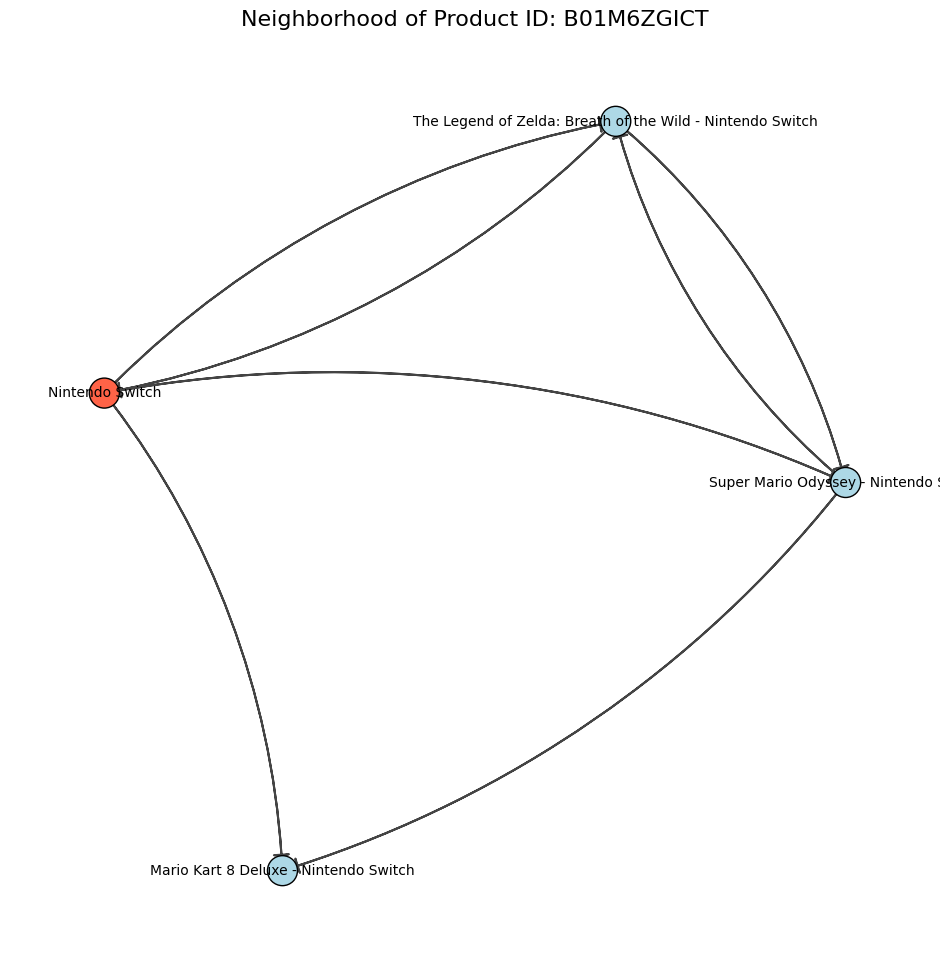

In [ ]:
target_id = 'B01M6ZGICT'

# Trova l'indice del nodo target
try:
    target_idx = g_also_bought.vs.find(name=target_id).index
except ValueError:
    print(f"⚠️ ID {target_id} non trovato nel grafo.")
    target_idx = None

if target_idx is not None:
    # Prende i vicini
    neighbor_indices = g_also_bought.neighbors(target_idx, mode="OUT")
    nodes_to_plot = [target_idx] + neighbor_indices

    # Crea sottografo
    ego_subgraph = g_also_bought.subgraph(nodes_to_plot)

    # Layout più leggibile
    layout = ego_subgraph.layout("fr")  # fr = Fruchterman-Reingold (più spazioso)

    # Colore nodi
    colors = ["tomato" if v["name"] == target_id else "lightblue" for v in ego_subgraph.vs]

    # Etichette semplificate (puoi usare 'title' o 'category')
    labels = [v["title"] if v["title"] else "?" for v in ego_subgraph.vs]

    # Disegno
    fig, ax = plt.subplots(figsize=(12, 12))
    ig.plot(
        ego_subgraph,
        target=ax,
        layout=layout,
        vertex_color=colors,
        vertex_label=labels,
        vertex_label_size=10,
        vertex_size=30,
        edge_arrow_size=1.2,
        edge_width=1.5,
        edge_curved=0.2,
        margin=80
    )
    plt.title(f"Neighborhood of Product ID: {target_id}", fontsize=16)
    plt.axis("off")
    plt.show()


#### Degree analysis
In this chapter, we will explore the potential applications of degree analysis using the 'Also_bought' relationship. Specifically, we will examine how analyzing the degree of each product node can provide insights into purchasing patterns, help identify central or highly co-purchased products, and support strategic decisions such as product placement, recommendation systems, and inventory management.

In [ ]:
def plot_degree_distribution(graph ,mode = None):
  degrees_also_bought = graph.degree(mode=mode)

  # Calculate the degree distribution
  degree_counts_also_bought = np.bincount(degrees_also_bought)

  # Create a corresponding list of degree values
  degree_values_also_bought = np.arange(len(degree_counts_also_bought))

  # Visualize the distribution
  plt.figure(figsize=(10, 6))
  plt.plot(degree_values_also_bought, degree_counts_also_bought, 'bo')
  plt.title('Degree Distribution in the Network', fontsize=16)
  plt.xlabel('Degree (number of connections)', fontsize=14)
  plt.ylabel('Number of nodes', fontsize=14)
  plt.yscale('log')
  plt.xscale('log')
  plt.grid(True, which="both", ls="--")
  plt.show()

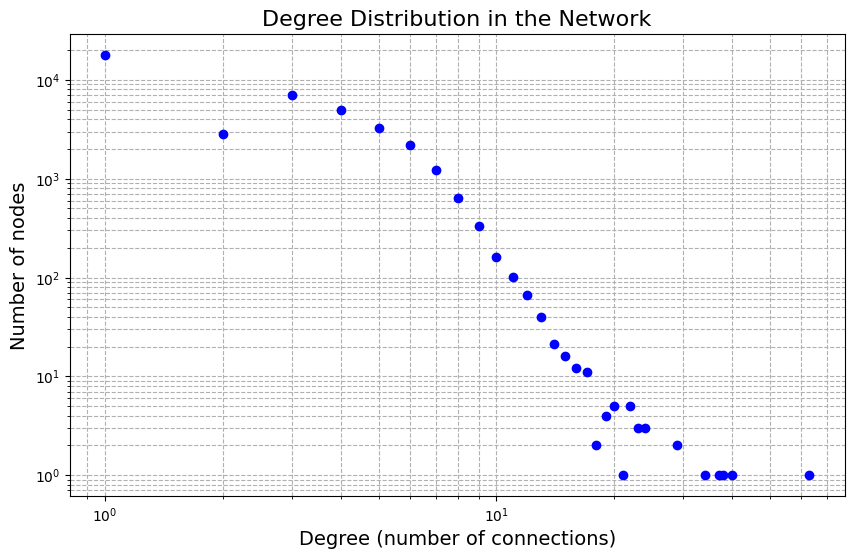

In [ ]:
plot_degree_distribution(g_also_bought)

In the degree distribution graph of outgoing (OUT) relations, the values are relatively low, indicating that each product is primarily associated with only a few others. This behavior can be leveraged to generate product recommendations. Similar to what was done for 'bought_together', these associations could be filtered using metrics such as average rating and number of reviews to identify the best products to recommend.

--------In--------
 


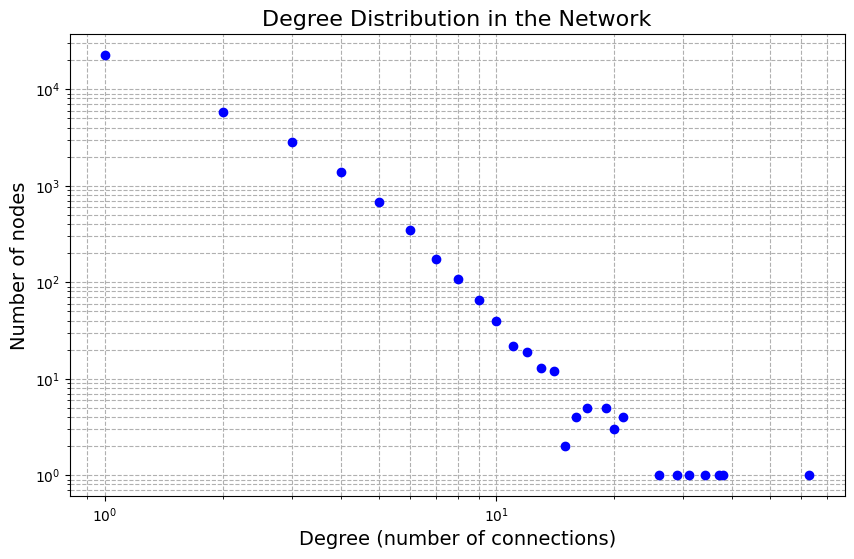

--------Out--------
 


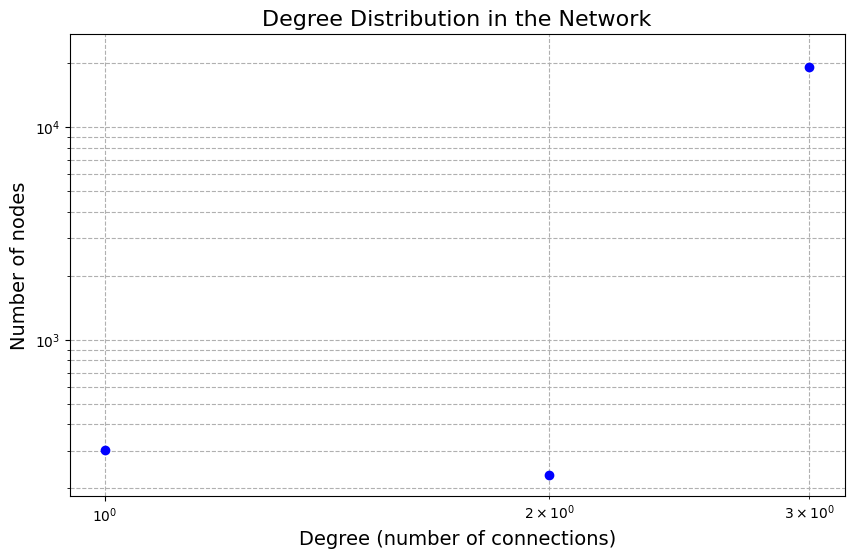

In [ ]:
print('--------In--------\n ')
plot_degree_distribution(g_also_bought, mode="IN")
print('--------Out--------\n ')
plot_degree_distribution(g_also_bought, mode="OUT")

In this case, we focus on the IN relationships — that is, products with a higher in-degree, meaning they are frequently referenced or associated by other products. These items may represent strong candidates for future recommendations, particularly when users return to the platform.
It is worth noting that 'bought_together' was useful for suggesting products the user might want immediately.

In [ ]:
degrees_also_bought = g_also_bought.degree(mode='IN')

# Find the min and max value
max_degree_also_bought = max(degrees_also_bought)
min_degree_also_bought = min(degrees_also_bought)

max_degree_vertex_also_bought = None
min_degree_vertex_also_bought = None

# Iterate to find the min and max grade for the nodes
for vertex in g_also_bought.vs:
    # If the grade of the vertex is equal to the max grade
    if vertex.degree() == max_degree_also_bought and max_degree_vertex_also_bought is None:
        max_degree_vertex_also_bought = vertex
        print(f"Vertex with maximum degree: ID = {vertex['name']}, Name = {vertex['title']}, Degree = {max_degree_also_bought}")

    # If the grade of the vertex is equal to the min grade
    if vertex.degree() == min_degree_also_bought and min_degree_vertex_also_bought is None:
        min_degree_vertex_also_bought = vertex
        print(f"Vertex with minimum degree: ID = {vertex['name']}, Name = {vertex['title']}, Degree = {min_degree_also_bought}")

    # Stop the cycle after finding the min and the max grade
    if max_degree_vertex_also_bought and min_degree_vertex_also_bought:
        break

Vertex with minimum degree: ID = B07P7QF4S2, Name = Cartellini COMUNIONE PERSONALIZZABILI per bomboniera, classico, croce, fiore, rettangolo, nuvola, ovale, quadrato, tondo, etichette, Prima Comunione, tag, Degree = 0
Vertex with maximum degree: ID = B07QGBVYJK, Name = None, Degree = 63


In [ ]:
# Create a list of (index, ID, score)
node_degree_also_bought = [(v.index, v["name"], degrees_also_bought[v.index]) for v in g_also_bought.vs]

top_n = 15
top_nodes = sorted(node_degree_also_bought, key=lambda x: x[2], reverse=True)[:top_n]

print(f"Top {top_n} nodes by Degree centrality:")
for idx, name, score in top_nodes:
    title = g_also_bought.vs[idx]["title"]
    print(f"ID: {name} | Title: {title} | Degree: {score:.2f}")

Top 15 nodes by Degree centrality:
ID: B07QGBVYJK | Title: None | Degree: 63.00
ID: B074M7FJDW | Title: None | Degree: 38.00
ID: B07P24R81S | Title: Gfone 8 Set di strumenti per manicure per unghie da 8 pezzi Set di manicure per forbici per unghie Clipper Kit pedicure e manicure 10,8 x 6,3 x 1,2 cm | Degree: 37.00
ID: B07DMJPV31 | Title: FIFA 19 - PlayStation 4 | Degree: 34.00
ID: B07PYGPZZF | Title: RFID Blocking Porta Carte di Credito, Leenou 2 Pezzi Portafoglio Carte Credito in Alluminio, Portafoglio Elegante Viaggi - Business, ID, Assicurazioni, di Debito, Donna e Uomo (9.6 * 6.5 * 1cm) | Degree: 31.00
ID: B0792HCFTG | Title: Echo Dot (3ª generazione) - Altoparlante intelligente con integrazione Alexa - Tessuto antracite | Degree: 29.00
ID: B07GFT2NS8 | Title: Rolsac - Cagliplast Rotolo con Scatola Esterna, Carta Pergamena, Multicolore, 39 x 33 cm, confezione da 24 | Degree: 26.00
ID: B00UFGMVFG | Title: Bruzzzler 200100001066, Ciminiera con impugnatura di sicurezza - accenditore, 

A high degree in an 'also bought' graph indicates behavioral centrality: these are products that aggregate user interest or trigger additional purchases:

- identify emerging trends,

- suggest targeted bundled offers,

- and even improve product categorization or recommendation systems.

Building on this, one possible extension would be to extract the neighborhoods of these highly connected products, in order to understand the origin and context of their associations. By analyzing which products are frequently linked to them, we could uncover purchase patterns or typical product combinations.

However, beyond identifying these neighborhoods, the next step could involve exploring whether these associations form cohesive clusters (e.g., around shared use cases or categories), or even training models to predict likely co-purchases based on topological proximity and shared metadata.

#### Betweeness Analysis

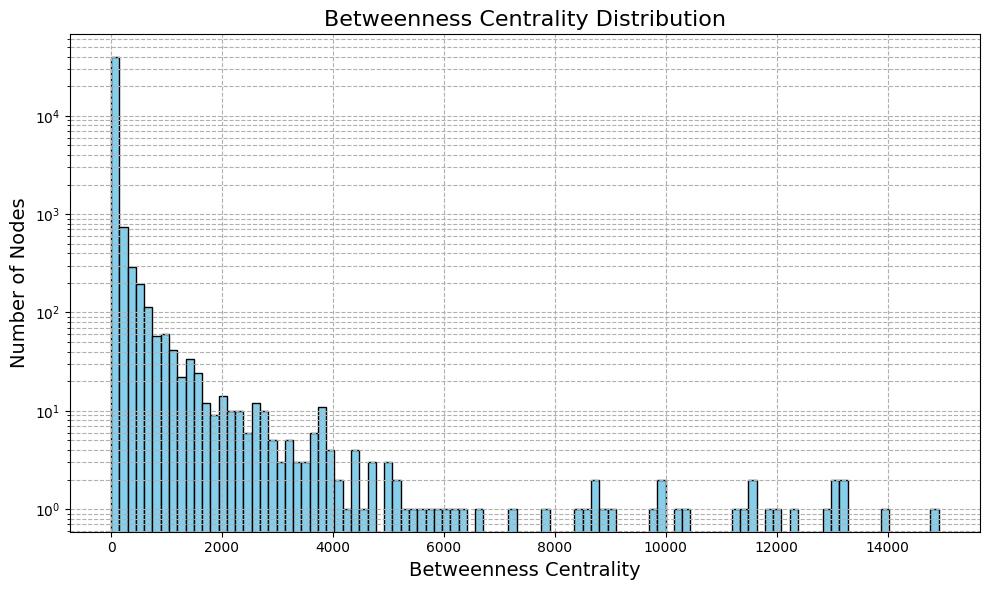

In [ ]:
betweenness_also_bought = g_also_bought.betweenness(directed=True)

plt.figure(figsize=(10, 6))
plt.hist(betweenness_also_bought, bins=100, color='skyblue', edgecolor='black')
plt.title('Betweenness Centrality Distribution', fontsize=16)
plt.xlabel('Betweenness Centrality', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.yscale('log')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [ ]:
# Create a list of (index, ID, score)
node_betweenness_not_normalized = [(v.index, v["name"], betweenness_also_bought[v.index]) for v in g.vs]

top_n = 15
top_nodes = sorted(node_betweenness_not_normalized, key=lambda x: x[2], reverse=True)[:top_n]

print(f"Top {top_n} nodes by betweenness centrality:")
for idx, name, score in top_nodes:
    title = g_also_bought.vs[idx]["title"]
    print(f"ID: {name} | Title: {title} | Betweenness: {score:.2f}")

Top 15 nodes by betweenness centrality:
ID: B017JI1DV0 | Title: Candy CCTOS 542XH Frigo Tavolo, 109 l, 39 dB(A), Inox | Betweenness: 14921.17
ID: B01L5IYCFO | Title: Ciarra, cappa aspirante con pannello argento, 60 cm, montaggio a parete, con ventola estrattore (argento) (nero) | Betweenness: 12945.67
ID: B07FND5P8R | Title: Casa [Vinile Bianco Autografato] (Esclusiva Amazon.it) | Betweenness: 12264.42
ID: B017J48NQC | Title: Ultimo: Colpa Delle Favole | Betweenness: 11948.42
ID: 8856646560 | Title: Casa | Betweenness: 11927.25
ID: B006O8B4XO | Title: Candy Microonde CMXG20D - Grill e App Cook-in, 20L, 40 Programmi Automatici, 700 W, Argento | Betweenness: 11613.17
ID: B00PIW715W | Title: Heidrun 1910 Coperchio per Microonde, 25 cm, Trasparente/Rosso | Betweenness: 11611.67
ID: B0056C6Z8I | Title: Ciarra, filtro di ricambio a carboni attivi per cappe CBCB/S6903 ed estrattori a ventola | Betweenness: 11235.25
ID: B00KM2Z77C | Title: Ciarra, cappa con aspiratore, da cucina, 90cm, in acci

In [ ]:
components = g_also_bought.clusters()
sorted_components = sorted(components.subgraphs(), key=lambda x: x.vcount(), reverse=True)
giant_component = sorted_components[0]
second_largest_component = sorted_components[1]

print("Giant component nodes:", giant_component.vcount())
print("Second component nodes:", second_largest_component.vcount())

/tmp/ipython-input-62-2235182660.py:1: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  components = g_also_bought.clusters()


Giant component nodes: 52
Second component nodes: 49


In [ ]:
# Parameters
min_nodes = 20  # minimum size to consider a component significant
top_n = 15      # number of top nodes to print per component

for i, comp in enumerate(components.subgraphs()):
    n = comp.vcount()
    if n < min_nodes:
        # Ignore components that are too small
        continue

    # Calculate betweenness and normalize
    bet = comp.betweenness()
    normalization_factor = (n - 1) * (n - 2) if n > 2 else 1

    node_betweenness = [
        (v.index, v["name"], bet[v.index] / normalization_factor)
        for v in comp.vs
    ]

    # Sort and select top_n nodes
    top_nodes = sorted(node_betweenness, key=lambda x: x[2], reverse=True)[:top_n]

    print(f"\nComponent {i} with {n} nodes - Top {top_n} nodes by normalized betweenness:")
    for idx, name, score in top_nodes:
        title = comp.vs[idx]["title"] if "title" in comp.vs[idx].attributes() else "N/A"
        print(f"ID: {name} | Title: {title} | Betweenness: {score:.4f}")



Component 30456 with 20 nodes - Top 15 nodes by normalized betweenness:
ID: B00WMOWORO | Title: Bticino S3625DE Adattatore con Spina Tedesca e Presa Bipasso, Bianco | Betweenness: 0.5468
ID: B07DRFR9W4 | Title: Presa Intelligente Wifi AISIRER Spina Intelligente Wifi Energy Monitor per Elettrodomestici Gestione Accesso Remoto tramite App Android e iOS Presa Wireless Funziona con Alexa,Google Assistant e IFTTT | Betweenness: 0.4883
ID: B07BTQJG6J | Title: Smart WiFi E27 Light socket, Aicase Intelligent WLAN [2 pezzi] Home Remote Control Light Lamp Bulb Holder Works with ALEXA e Google Home-white (Smart WiFi E27 Light socket) | Betweenness: 0.3918
ID: B00IAURV36 | Title: BTicino S3623DE Adattatore Presa Tedesca, Bianco, 10A | Betweenness: 0.3918
ID: B00OU0IALW | Title: BTicino S3624DE Adattatore Presa Tedesca, Bianco, 16A | Betweenness: 0.2690
ID: B00ABJRIEQ | Title: BTicino S3610D Adattatore Tris con 1 Presa Tedesca 2 Prese, 10A, Colore Bianco, 2200 W, 250 V | Betweenness: 0.2164
ID: B0

#### Aassortativity

In [ ]:
assortativity_degree = g_also_bought.assortativity_degree(directed=True)
print(f"Degree assortativity coefficient: {assortativity_degree:.4f}")

Degree assortativity coefficient: -0.0139


#### PageRank

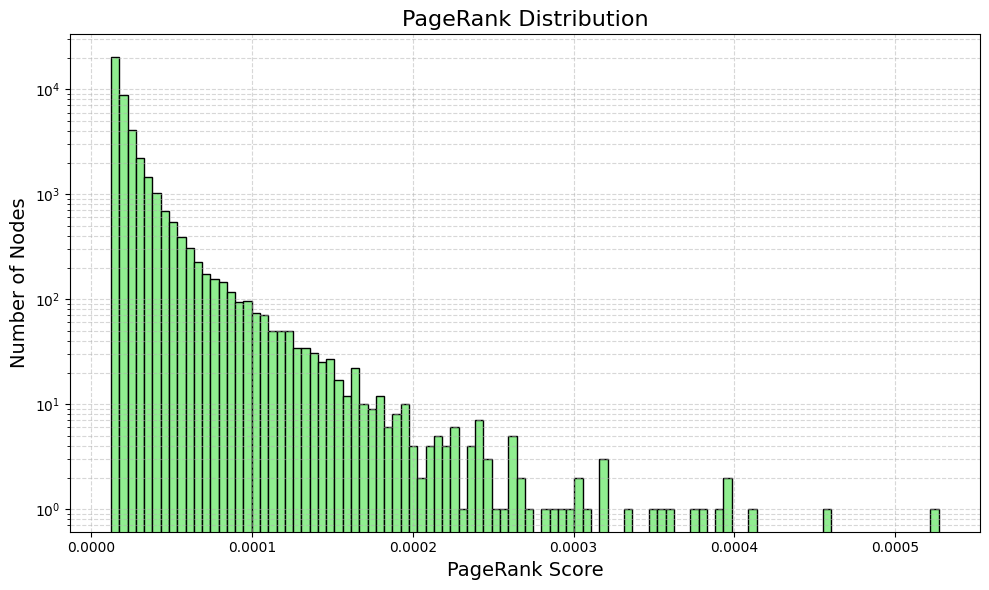

In [ ]:
# Calcolo del PageRank per grafo diretto
pagerank_scores = g_also_bought.pagerank(directed=True)

# Visualizzazione distribuzione PageRank
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(pagerank_scores, bins=100, color='lightgreen', edgecolor='black')
plt.title("PageRank Distribution", fontsize=16)
plt.xlabel("PageRank Score", fontsize=14)
plt.ylabel("Number of Nodes", fontsize=14)
plt.yscale('log')  # scala logaritmica per evidenziare la distribuzione spesso molto sbilanciata
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
top_n = 10
top_nodes = sorted(zip(g_also_bought.vs["name"], pagerank_scores), key=lambda x: x[1], reverse=True)[:top_n]

for pid, score in top_nodes:
    title = g_also_bought.vs.find(name=pid)["title"] if "title" in g_also_bought.vs.attributes() else "N/A"
    print(f"ID: {pid} | Title: {title} | PageRank: {score:.6f}")


ID: B07KKY7MP7 | Title: Giochi Preziosi LOL Surprise Hairgoals, Lol con Capelli Pettinabili, 15 Livelli, Modelli Assortiti | PageRank: 0.000527
ID: B07QGBVYJK | Title: None | PageRank: 0.000456
ID: B07NW1X53H | Title: Dragon Quest XI Echi di un'era perduta -Definitive Edition - Nintendo Switch | PageRank: 0.000409
ID: B07BK7SWNJ | Title: L.O.L. Surprise UNDER WRAPS Nuova SERIE 2 Bambola Capsula ORIGINALE MGA Entertaniment 552048E7C | PageRank: 0.000398
ID: B07NVZN65B | Title: Astral Chain - Nintendo Switch | PageRank: 0.000398
ID: B000BNSYHW | Title: D'Addario PW-LMN Detergente Planet Waves Lemon Oil | PageRank: 0.000389
ID: B00MDIVOMK | Title: Maurer 93193 - Adattatore Doppio Schuko, 16 A, 250 V | PageRank: 0.000379
ID: B07BK7QQGL | Title: L.O.L Surprise! Lil Sister Serie 4-2A da collezione, 1 unità | PageRank: 0.000377
ID: B00ZA6URIY | Title: Wpro SKS101 Kit di accatastamento per lavatrici e asciugatrici | PageRank: 0.000362
ID: B07NBZ17SS | Title: Luigi's Mansion 3 - Nintendo Switch

#### Clustering

##### Pre-Processing

In [ ]:
min_nodes = 10  # Threshold for keeping meaningful components
components = g_also_bought.connected_components()

# Keep only components with sufficient size
filtered_subgraphs = [comp for comp in components.subgraphs() if comp.vcount() >= min_nodes]

# Start with the first subgraph
g_filtered_also_bought = filtered_subgraphs[0]

# Iteratively union the others
for sg in filtered_subgraphs[1:]:
    g_filtered_also_bought = g_filtered_also_bought.disjoint_union(sg)

print(f"Filtered graph has {g_filtered_also_bought.vcount()} nodes and {g_filtered_also_bought.ecount()} edges")

Filtered graph has 1177 nodes and 2768 edges


In [ ]:
for v in g_filtered_also_bought.vs[:5]:
    print(f"Index {v.index} → {v.attributes()}")

Index 0 → {'name': 'B07H4P3X4W', 'title': 'BRACCIALE IN ACCIAIO 316L CON CIONDOLO"IL CUORE DI UNA NONNA"', 'category': 'jewelry', 'price': {'$numberInt': '29'}, 'avg_rating': {'$numberDouble': '4.8'}, 'reviews_number': {'$numberInt': '12'}, 'questions_number': {'$numberInt': '4'}, 'versions': []}
Index 1 → {'name': 'B07BRYZ7N4', 'title': 'Kidult Family - bracciale in acciaio Migliore zia per sempre 731319', 'category': 'jewelry', 'price': {'$numberInt': '29'}, 'avg_rating': {'$numberInt': '5'}, 'reviews_number': {'$numberInt': '7'}, 'questions_number': {'$numberInt': '3'}, 'versions': []}
Index 2 → {'name': 'B0759QV7PK', 'title': 'KIDULT - BRACCIALE IN ACCIAIO 316L E CIONDOLO CUORE CON SCRITTA "DOVE LA VITA HA INIZIO ..." COD 731259', 'category': 'jewelry', 'price': {'$numberInt': '29'}, 'avg_rating': {'$numberDouble': '4.8'}, 'reviews_number': {'$numberInt': '56'}, 'questions_number': {'$numberInt': '11'}, 'versions': []}
Index 3 → {'name': 'B07BTGQL9W', 'title': 'KIDULT LIFE LOVE BRA

##### Community Detection
We use label propagation because Louvain need to be undirected.

In [ ]:
communities = g_filtered_also_bought.community_label_propagation()
g_filtered_also_bought.vs["community"] = communities.membership
modularity_score = g_filtered_also_bought.modularity(g_filtered_also_bought.vs["community"])
num_clusters = len(set(communities.membership))
print(f"Detected {num_clusters} clusters with modularity score: {modularity_score:.4f}")

Detected 150 clusters with modularity score: 0.9148


In [ ]:
for v in g_filtered_also_bought.vs[:5]:
    print(f"Index {v.index} → {v.attributes()}")

Index 0 → {'name': 'B07H4P3X4W', 'title': 'BRACCIALE IN ACCIAIO 316L CON CIONDOLO"IL CUORE DI UNA NONNA"', 'category': 'jewelry', 'price': {'$numberInt': '29'}, 'avg_rating': {'$numberDouble': '4.8'}, 'reviews_number': {'$numberInt': '12'}, 'questions_number': {'$numberInt': '4'}, 'versions': [], 'community': 0}
Index 1 → {'name': 'B07BRYZ7N4', 'title': 'Kidult Family - bracciale in acciaio Migliore zia per sempre 731319', 'category': 'jewelry', 'price': {'$numberInt': '29'}, 'avg_rating': {'$numberInt': '5'}, 'reviews_number': {'$numberInt': '7'}, 'questions_number': {'$numberInt': '3'}, 'versions': [], 'community': 0}
Index 2 → {'name': 'B0759QV7PK', 'title': 'KIDULT - BRACCIALE IN ACCIAIO 316L E CIONDOLO CUORE CON SCRITTA "DOVE LA VITA HA INIZIO ..." COD 731259', 'category': 'jewelry', 'price': {'$numberInt': '29'}, 'avg_rating': {'$numberDouble': '4.8'}, 'reviews_number': {'$numberInt': '56'}, 'questions_number': {'$numberInt': '11'}, 'versions': [], 'community': 0}
Index 3 → {'nam

In [ ]:
unique_categories = Counter(g_also_bought.vs['category'])
print(unique_categories)

unique_categories = Counter(g_filtered_also_bought.vs['category'])
print(unique_categories)

unique_community = Counter(g_filtered_also_bought.vs['community'])
print(unique_community)

Counter({None: 21025, 'kitchen': 1784, 'electronics': 1143, 'tools': 1125, 'books': 993, 'apparel': 946, 'sports': 887, 'english-books': 873, 'jewelry': 846, 'hpc': 839, 'toys': 800, 'baby': 734, 'garden': 697, 'music': 672, 'shoes': 653, 'luggage': 638, 'beauty': 617, 'dvd': 616, 'musical-instruments': 601, 'lighting': 569, 'watch': 563, 'videogames': 558, 'office': 512, 'pc': 508, 'grocery': 488, 'pet-supplies': 456, 'appliances': 418, 'handmade': 392, 'industrial': 381, 'automotive': 72, 'luxury-beauty': 30, 'NoStoreName': 20, 'amazon-home': 12, 'amazon-ereaders': 5, 'fiona-hardware-acc': 5, 'apple-devices': 4, 'amazon-smp': 1, 'software': 1})
Counter({'watch': 111, 'musical-instruments': 102, 'music': 93, 'videogames': 79, 'apparel': 71, 'dvd': 70, 'appliances': 68, 'pet-supplies': 60, 'toys': 59, 'office': 57, 'kitchen': 49, 'jewelry': 48, 'pc': 48, 'hpc': 39, 'electronics': 36, 'tools': 32, 'baby': 27, 'sports': 25, 'grocery': 24, 'industrial': 18, 'lighting': 17, 'garden': 15, '

##### Interpretation: Label each cluster by dominant category or theme
Thanks to this, we could go and show sub-portions of graphs related to the category we want to study, and in case, find the best product for that specific type. In the case of understanding which cluster it belongs to, we can conduct a search based on the title and understand to which part the product belongs.

In [ ]:
cluster_labels = {}
for cluster_id in range(num_clusters):
    nodes_in_cluster = g_filtered_also_bought.vs.select(community=cluster_id)
    categories = nodes_in_cluster["category"]

    if categories:
        # Count all the categories
        category_counts = Counter(categories)
        # Categories most common
        most_common_cat, most_common_count = category_counts.most_common(1)[0]
        # Generate a string with all categories and their respective frequencies
        all_categories_str = ", ".join([f"{cat} ({count})" for cat, count in category_counts.items()])
        # Combine the dominant category with the complete list.
        label_str = f"| Dominant: {most_common_cat} ({most_common_count}) -> All: {all_categories_str}"
    else:
        label_str = "Unknown"

    cluster_labels[cluster_id] = label_str

print("\nCluster interpretation (all categories with counts and dominant category):")
for cid, label in cluster_labels.items():
    print(f"Cluster {cid}: {label}")



Cluster interpretation (all categories with counts and dominant category):
Cluster 0: | Dominant: jewelry (8) -> All: jewelry (8)
Cluster 1: | Dominant: jewelry (3) -> All: jewelry (3)
Cluster 2: | Dominant: music (9) -> All: music (9)
Cluster 3: | Dominant: music (3) -> All: music (3)
Cluster 4: | Dominant: office (4) -> All: office (4), electronics (3), pc (3)
Cluster 5: | Dominant: pet-supplies (4) -> All: pet-supplies (4), office (1), kitchen (2)
Cluster 6: | Dominant: pet-supplies (4) -> All: pet-supplies (4)
Cluster 7: | Dominant: appliances (7) -> All: appliances (7), kitchen (3)
Cluster 8: | Dominant: apparel (4) -> All: apparel (4)
Cluster 9: | Dominant: apparel (6) -> All: apparel (6)
Cluster 10: | Dominant: office (7) -> All: office (7), pc (3)
Cluster 11: | Dominant: toys (2) -> All: english-books (1), toys (2), music (1), apparel (1)
Cluster 12: | Dominant: watch (5) -> All: electronics (1), watch (5)
Cluster 13: | Dominant: kitchen (5) -> All: kitchen (5), industrial (3)

An example

Cluster 15 subgraph:
Number of nodes: 3
Number of edges: 4


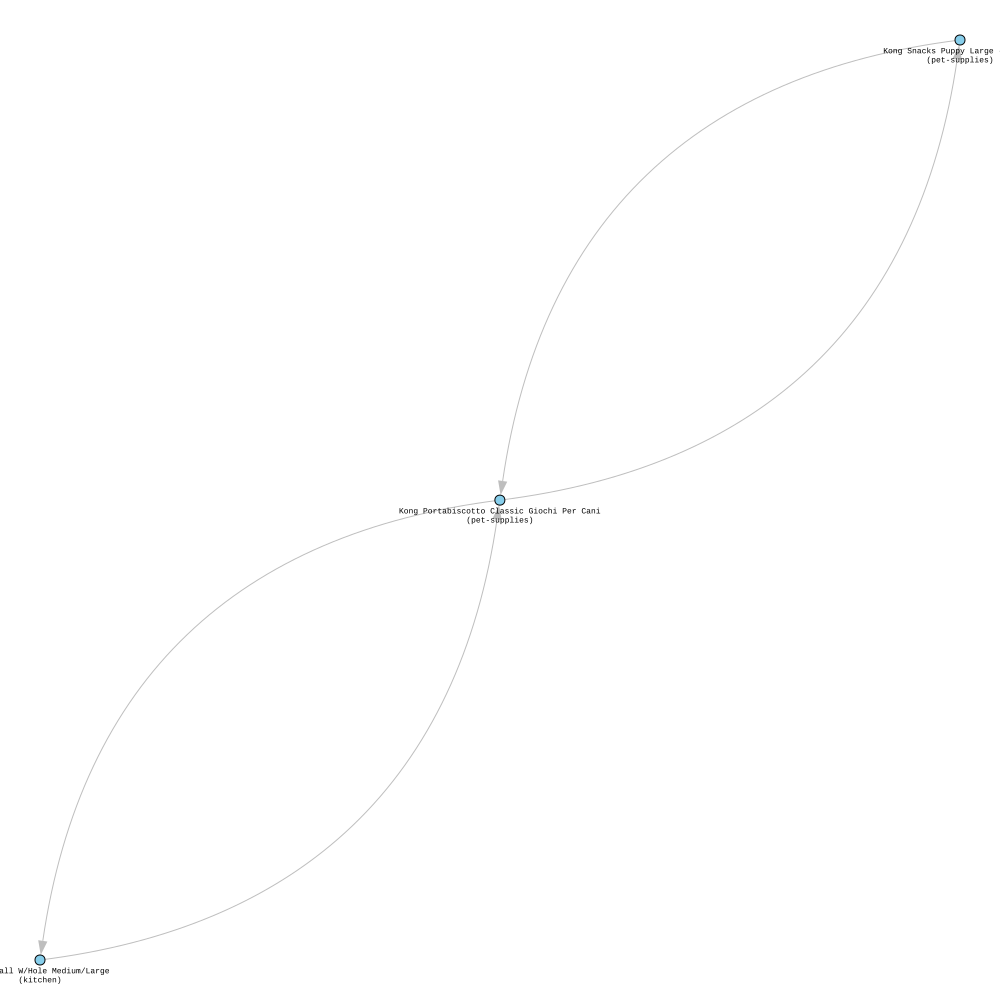

In [ ]:
# Look one sample
cluster_id = 15
subgraph = g_filtered_also_bought.subgraph(g_filtered_also_bought.vs.select(community=cluster_id))

print(f"Cluster {cluster_id} subgraph:")
print(f"Number of nodes: {subgraph.vcount()}")
print(f"Number of edges: {subgraph.ecount()}")

layout = subgraph.layout("fr")  # Layout Force-directed

# Create labe combine category and title
labels = []
for v in subgraph.vs:
    name = v["title"] if "title" in v.attributes() else "N/A"
    category = v["category"] if "category" in v.attributes() else "N/A"
    labels.append(f"{name}\n({category})")

ig.plot(
    subgraph,
    layout=layout,
    vertex_label=labels,
    vertex_size=10,
    bbox=(1000, 1000),
    margin=40,
    vertex_color="skyblue",
    edge_color="gray",
    vertex_label_size=8,
    vertex_label_dist=1.5
)

In [ ]:
all_categories = [v["category"] for v in g_also_bought.vs if v["category"] is not None]
category_counts = Counter(all_categories)

print(f"Unique categories: {len(category_counts)}")
print("Top categories:")
for cat, count in category_counts.most_common(37):
    print(f"{cat}: {count} nodi")

Unique categories: 37
Top categories:
kitchen: 1784 nodi
electronics: 1143 nodi
tools: 1125 nodi
books: 993 nodi
apparel: 946 nodi
sports: 887 nodi
english-books: 873 nodi
jewelry: 846 nodi
hpc: 839 nodi
toys: 800 nodi
baby: 734 nodi
garden: 697 nodi
music: 672 nodi
shoes: 653 nodi
luggage: 638 nodi
beauty: 617 nodi
dvd: 616 nodi
musical-instruments: 601 nodi
lighting: 569 nodi
watch: 563 nodi
videogames: 558 nodi
office: 512 nodi
pc: 508 nodi
grocery: 488 nodi
pet-supplies: 456 nodi
appliances: 418 nodi
handmade: 392 nodi
industrial: 381 nodi
automotive: 72 nodi
luxury-beauty: 30 nodi
NoStoreName: 20 nodi
amazon-home: 12 nodi
amazon-ereaders: 5 nodi
fiona-hardware-acc: 5 nodi
apple-devices: 4 nodi
amazon-smp: 1 nodi
software: 1 nodi


##### Actionable Insights
Intra and inter clusters betwenness, to find the best products for each cluster and the best products to connect different clusters.

This graph is identical to the one from the betweenness analysis because the nodes remain the same; no nodes were removed due to being too small.

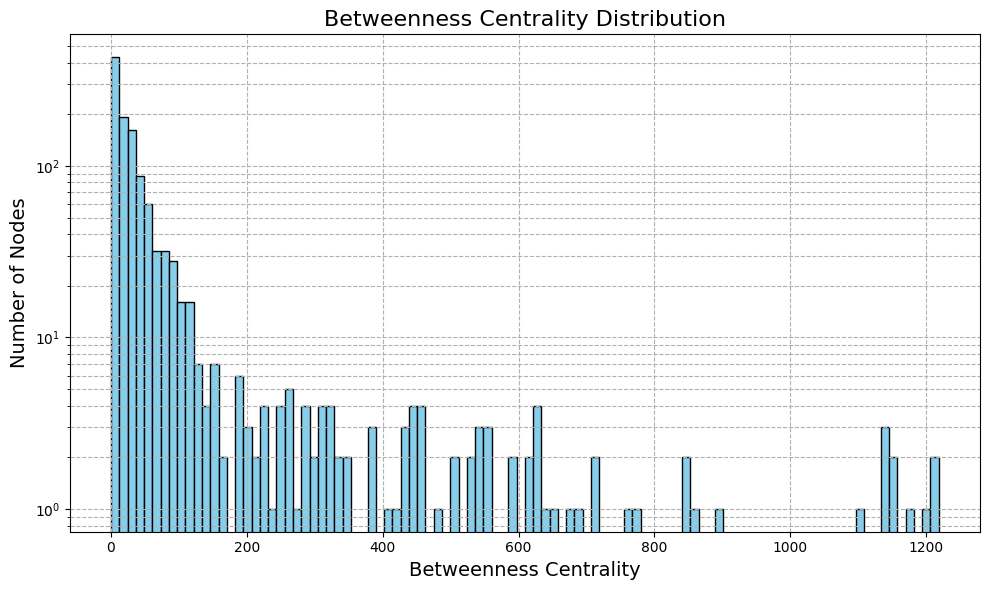

In [ ]:
bet = g_filtered_also_bought.betweenness()

plt.figure(figsize=(10, 6))
plt.hist(bet, bins=100, color='skyblue', edgecolor='black')
plt.title('Betweenness Centrality Distribution', fontsize=16)
plt.xlabel('Betweenness Centrality', fontsize=14)
plt.ylabel('Number of Nodes', fontsize=14)
plt.yscale('log')
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

In [ ]:
# Identify "bridge nodes" = high betweenness
g_filtered_also_bought.vs["betweenness_cluster"] = bet
threshold = np.percentile(bet, 97)
bridge_nodes = g_filtered_also_bought.vs.select(lambda v: v["betweenness_cluster"] >= threshold)

print(f"\nTop bridge nodes (potential cross-segment promoters):")
for node in bridge_nodes:
    print(f"ID: {node['name']} | Category: {node['category']} | Community:{node['community']} |Betweenness: {node['betweenness_cluster']:.2f}")

# Example: identify underrepresented clusters
min_cluster_size = 10
print("\nUnderrepresented clusters (small but valid):")
for cid in range(num_clusters):
    cluster_nodes = g_filtered_also_bought.vs.select(community=cid)
    if len(cluster_nodes) <= min_cluster_size:
        print(f"Cluster {cid} (size={len(cluster_nodes)}): Dominant category → {cluster_labels[cid]}")


Top bridge nodes (potential cross-segment promoters):
ID: B01N3W06XC | Category: kitchen | Community:73 |Betweenness: 634.00
ID: B00KS0VP2O | Category: appliances | Community:73 |Betweenness: 777.33
ID: B06XXCD6N7 | Category: appliances | Community:74 |Betweenness: 845.00
ID: B004WLMBTG | Category: appliances | Community:74 |Betweenness: 718.00
ID: B01MT8B9OC | Category: appliances | Community:73 |Betweenness: 547.33
ID: B06XPF4B8R | Category: appliances | Community:74 |Betweenness: 1174.00
ID: B000WD0HFI | Category: kitchen | Community:77 |Betweenness: 648.17
ID: B073FQ4HT9 | Category: appliances | Community:74 |Betweenness: 541.67
ID: B0050IJEWW | Category: kitchen | Community:77 |Betweenness: 621.17
ID: B06XQC7FM1 | Category: appliances | Community:75 |Betweenness: 671.00
ID: B078WLY5KL | Category: appliances | Community:75 |Betweenness: 632.00
ID: B0096PK2MG | Category: kitchen | Community:77 |Betweenness: 1144.00
ID: B00H43LCTO | Category: appliances | Community:74 |Betweenness: 

Let’s examine the distribution of the top 20 clusters. As shown in the graph, some clusters exhibit a high degree of heterogeneity.

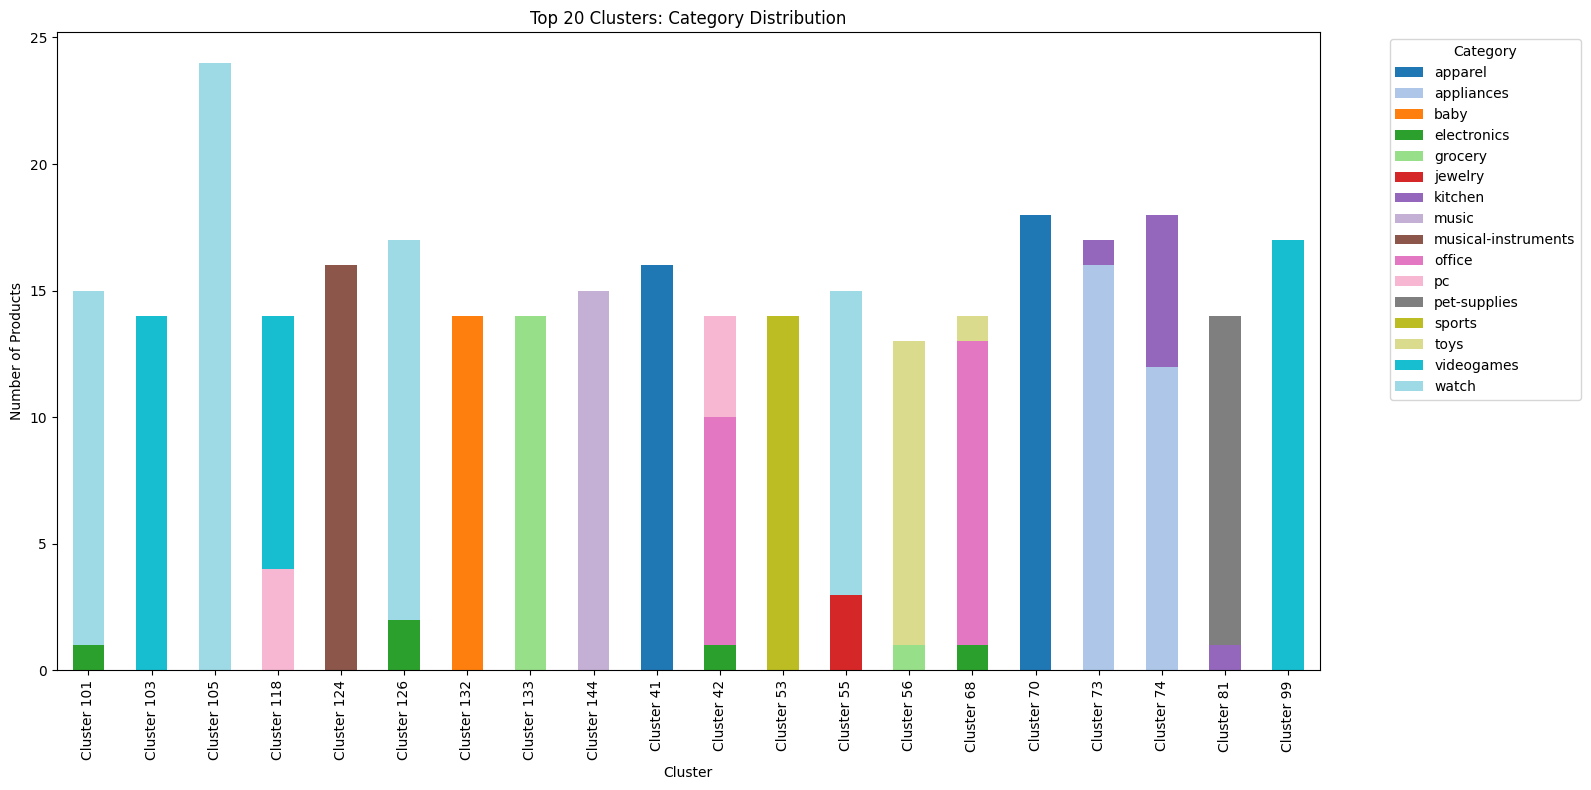

In [ ]:
cluster_sizes = {cid: len(g_filtered_also_bought.vs.select(community=cid)) for cid in range(num_clusters)}

top_n = 20
top_clusters = sorted(cluster_sizes.items(), key=lambda x: x[1], reverse=True)[:top_n]
top_cluster_ids = [cid for cid, _ in top_clusters]

data = []

for cluster_id in top_cluster_ids:
    nodes = g_filtered_also_bought.vs.select(community=cluster_id)
    cat_counts = Counter(nodes["category"])
    for cat, count in cat_counts.items():
        if cat:  # escludi None
            data.append({"Cluster": f"Cluster {cluster_id}", "Category": cat, "Count": count})

df = pd.DataFrame(data)

pivot_df = df.pivot_table(index="Cluster", columns="Category", values="Count", fill_value=0)

pivot_df.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='tab20')
plt.title(f"Top {top_n} Clusters: Category Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Category')
plt.tight_layout()
plt.show()


Cluster 42 subgraph:
Number of nodes: 14
Number of edges: 37


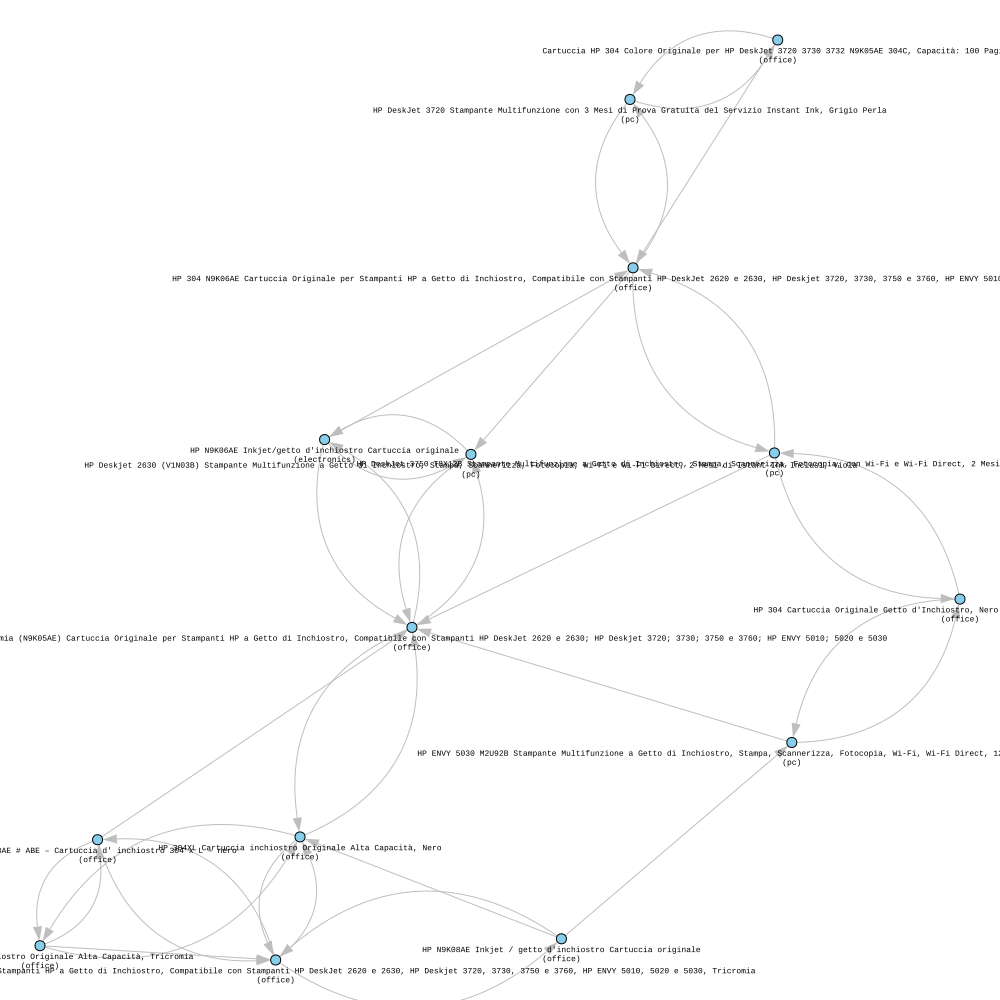

In [ ]:
# Look one sample
cluster_id = 42
subgraph = g_filtered_also_bought.subgraph(g_filtered_also_bought.vs.select(community=cluster_id))

print(f"Cluster {cluster_id} subgraph:")
print(f"Number of nodes: {subgraph.vcount()}")
print(f"Number of edges: {subgraph.ecount()}")

layout = subgraph.layout("fr")  # Layout Force-directed

# Create labe combine category and title
labels = []
for v in subgraph.vs:
    name = v["title"] if "title" in v.attributes() else "N/A"
    category = v["category"] if "category" in v.attributes() else "N/A"
    labels.append(f"{name}\n({category})")

ig.plot(
    subgraph,
    layout=layout,
    vertex_label=labels,
    vertex_size=10,
    bbox=(1000, 1000),
    margin=40,
    vertex_color="skyblue",
    edge_color="gray",
    vertex_label_size=8,
    vertex_label_dist=1.5
)


Another thing we could do might be to take the individual clusters and perform analysis for all 331 clusters found by identifying the best products based on betweenness and degree.

In [ ]:
# Compute the centrality
if "betweenness" not in g_filtered_also_bought.vs.attributes():
    betweenness = g_filtered_also_bought.betweenness()
    g_filtered_also_bought.vs["betweenness"] = betweenness

if "degree" not in g_filtered_also_bought.vs.attributes():
    degree = g_filtered_also_bought.degree()
    g_filtered_also_bought.vs["degree"] = degree

num_clusters = len(set(g_filtered_also_bought.vs["community"]))

# Treshold changable
betw_threshold_percentile = 90
degree_threshold_percentile = 90

print(f"Analyzing {num_clusters} clusters for top products by betweenness and degree...\n")

for cluster_id in range(num_clusters):
    nodes_in_cluster = g_filtered_also_bought.vs.select(community=cluster_id)

    betw_values = nodes_in_cluster["betweenness"]
    degree_values = nodes_in_cluster["degree"]

    # Calcola soglie per il cluster attuale
    betw_threshold = np.percentile(betw_values, betw_threshold_percentile)
    degree_threshold = np.percentile(degree_values, degree_threshold_percentile)

    # Seleziona nodi sopra soglia
    top_betw_nodes = [v for v in nodes_in_cluster if v["betweenness"] >= betw_threshold]
    top_degree_nodes = [v for v in nodes_in_cluster if v["degree"] >= degree_threshold]

    print(f"Cluster {cluster_id}:")
    print(f" Top Betweenness threshold ({betw_threshold_percentile} percentile): {betw_threshold:.4f}")
    print(f" Top Degree threshold ({degree_threshold_percentile} percentile): {degree_threshold:.4f}")
    print(f" Nodes with top betweenness: {len(top_betw_nodes)}")
    for node in top_betw_nodes:
        print(f"  - {node['name']} | Betweenness: {node['betweenness']:.4f} | Degree: {node['degree']} | Category: {node['category']}")

    print(f" Nodes with top degree: {len(top_degree_nodes)}")
    for node in top_degree_nodes:
        print(f"  - {node['name']} | Degree: {node['degree']} | Betweenness: {node['betweenness']:.4f} | Category: {node['category']}")

    print("\n" + "-"*40 + "\n")


Analyzing 150 clusters for top products by betweenness and degree...

Cluster 0:
 Top Betweenness threshold (90 percentile): 34.3500
 Top Degree threshold (90 percentile): 6.6000
 Nodes with top betweenness: 1
  - B0759QV7PK | Betweenness: 41.0000 | Degree: 8 | Category: jewelry
 Nodes with top degree: 1
  - B0759QV7PK | Degree: 8 | Betweenness: 41.0000 | Category: jewelry

----------------------------------------

Cluster 1:
 Top Betweenness threshold (90 percentile): 24.0000
 Top Degree threshold (90 percentile): 4.6000
 Nodes with top betweenness: 1
  - B07BT925NC | Betweenness: 26.0000 | Degree: 5 | Category: jewelry
 Nodes with top degree: 1
  - B07BT925NC | Degree: 5 | Betweenness: 26.0000 | Category: jewelry

----------------------------------------

Cluster 2:
 Top Betweenness threshold (90 percentile): 48.2000
 Top Degree threshold (90 percentile): 6.2000
 Nodes with top betweenness: 1
  - B07KHDZRLT | Betweenness: 49.0000 | Degree: 7 | Category: music
 Nodes with top degree: 

As we can see from this code, the community_label_propagation clusters has some inter cluster edges

In [ ]:
inter_cluster_edges = []
inter_cluster_indices = []

for idx, e in enumerate(g_filtered_also_bought.es):
    src = g_filtered_also_bought.vs[e.source]
    tgt = g_filtered_also_bought.vs[e.target]
    if src["community"] != tgt["community"]:
        inter_cluster_edges.append(e)
        inter_cluster_indices.append(idx)

print(f"Number of edges inter-cluster: {len(inter_cluster_edges)}")

Numero di archi inter-cluster: 212


Now we can see an example of a betwenness edge.


Top 15 bridge nodes between clusters (by betweenness):
ID: B07Q32VJBX | Title: Casa | Community: 147 → Connects to: 145 | Betweenness: 1218.3333
ID: B07PHHXD7D | Title: Ultimo: Colpa Delle Favole | Community: 145 → Connects to: 147 | Betweenness: 1213.3333
ID: B07NRFC6MN | Title: Rehab | Community: 146 → Connects to: 144 | Betweenness: 1151.0333
ID: B01M0PC654 | Title: Candy CMXG20DR Microonde con grill e app Cook-in, 20 litri, colore Rosso | Community: 74 → Connects to: 77 | Betweenness: 1150.0000
ID: B0096PK2MG | Title: Heidrun 1911 Coperchio per Microonde, 30 cm, Trasparente/Rosso | Community: 77 → Connects to: 74 | Betweenness: 1144.0000
ID: B07PZX92RL | Title: Scialla Semper | Community: 144 → Connects to: 146 | Betweenness: 1137.3667
ID: B07NTL7J7V | Title: Casa [Vinile Bianco Autografato] (Esclusiva Amazon.it) | Community: 147 → Connects to: 146 | Betweenness: 1098.3333
ID: B07P5TNK7T | Title: MM Vol. 3 | Community: 148 → Connects to: 144 | Betweenness: 897.4167
ID: B07NRTD72N 

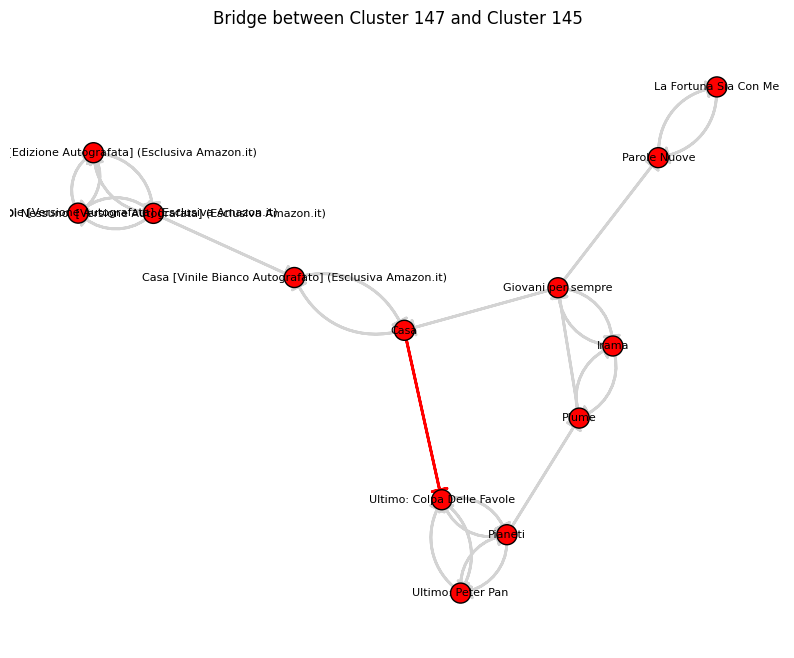

In [ ]:
# Step 1: Compute betweenness centrality
betweenness = g_filtered_also_bought.betweenness(directed=True)
g_filtered_also_bought.vs["betweenness"] = betweenness

# Step 2: Trova i nodi coinvolti negli archi inter-cluster
inter_cluster_connections = defaultdict(set)
inter_cluster_nodes = set()

for e in inter_cluster_edges:
    src = g_filtered_also_bought.vs[e.source]
    tgt = g_filtered_also_bought.vs[e.target]
    inter_cluster_nodes.add(src.index)
    inter_cluster_nodes.add(tgt.index)

    inter_cluster_connections[src.index].add(tgt["community"])
    inter_cluster_connections[tgt.index].add(src["community"])

# Step 3: Ordina i nodi ponte in base alla betweenness
bridge_nodes = [
    (v.index, v["name"], v["betweenness"], inter_cluster_connections.get(v.index, set()))
    for v in g_filtered_also_bought.vs
    if v.index in inter_cluster_nodes
]
top_bridge_nodes = sorted(bridge_nodes, key=lambda x: x[2], reverse=True)

# Step 4: Stampa i Top-N bridge nodes con info sulle community collegate
top_n = 15
print(f"\nTop {top_n} bridge nodes between clusters (by betweenness):")
for idx, node_id, score, connected_communities in top_bridge_nodes[:top_n]:
    node = g_filtered_also_bought.vs[idx]
    current_comm = node["community"]
    other_comms = ", ".join(str(c) for c in connected_communities if c != current_comm)
    print(f"ID: {node_id} | Title: {node['title']} | Community: {current_comm} → Connects to: {other_comms} | Betweenness: {score:.4f}")

# Step 5: Visualizza il collegamento del top nodo ponte tra due cluster
top_node_index = top_bridge_nodes[0][0]
related_edges = [
    e for e in inter_cluster_edges
    if e.source == top_node_index or e.target == top_node_index
]

if related_edges:
    top_edge = related_edges[0]
    src_idx = top_edge.source
    tgt_idx = top_edge.target
    src_comm = g_filtered_also_bought.vs[src_idx]["community"]
    tgt_comm = g_filtered_also_bought.vs[tgt_idx]["community"]

    # Seleziona i nodi delle due community
    cluster_nodes = g_filtered_also_bought.vs.select(
        lambda v: v["community"] == src_comm or v["community"] == tgt_comm
    )
    subgraph = g_filtered_also_bought.subgraph(cluster_nodes)

    # Colora l'arco ponte in rosso
    edge_colors = []
    for e in subgraph.es:
        orig_src = cluster_nodes[e.source]["name"]
        orig_tgt = cluster_nodes[e.target]["name"]
        if (orig_src == g_filtered_also_bought.vs[src_idx]["name"] and
            orig_tgt == g_filtered_also_bought.vs[tgt_idx]["name"]):
            edge_colors.append("red")
        else:
            edge_colors.append("lightgray")

    # Disegna il subgrafo
    layout = subgraph.layout("fr")
    plt.figure(figsize=(10, 8))
    ig.plot(
        subgraph,
        layout=layout,
        edge_color=edge_colors,
        vertex_size=20,
        vertex_label=subgraph.vs["title"],
        vertex_label_size=8,
        edge_arrow_size=0.6,
        target=plt.gca()
    )
    plt.title(f"Bridge between Cluster {src_comm} and Cluster {tgt_comm}")
    plt.axis("off")
    plt.show()
else:
    print("⚠️ No inter-cluster edges found for the top bridge node.")


This comprehensive analysis provided a multi-level understanding of the product co-purchase network. Starting from identifying key products by centrality, we uncovered the community structure using label propagation clustering, and differentiated between intra-cluster cohesion and inter-cluster bridging products via edge betweenness. These insights facilitate targeted marketing, recommendation strategies, and potential product bundling, grounded on the topology and category distribution of the network.

#### GateWay Products
We now proceed to make some considerations regarding the combination of different centrality metrics, such as the identification of hubs and authorities, integrating them with other measures to uncover various characteristics of the products.

In [ ]:
# Calcolo hub e authority score per grafo diretto
hub_scores = g_also_bought.hub_score(weights=None)
authority_scores = g_also_bought.authority_score(weights=None)

# Assegna gli score come attributi del nodo
g_also_bought.vs["hub_score"] = hub_scores
g_also_bought.vs["authority_score"] = authority_scores

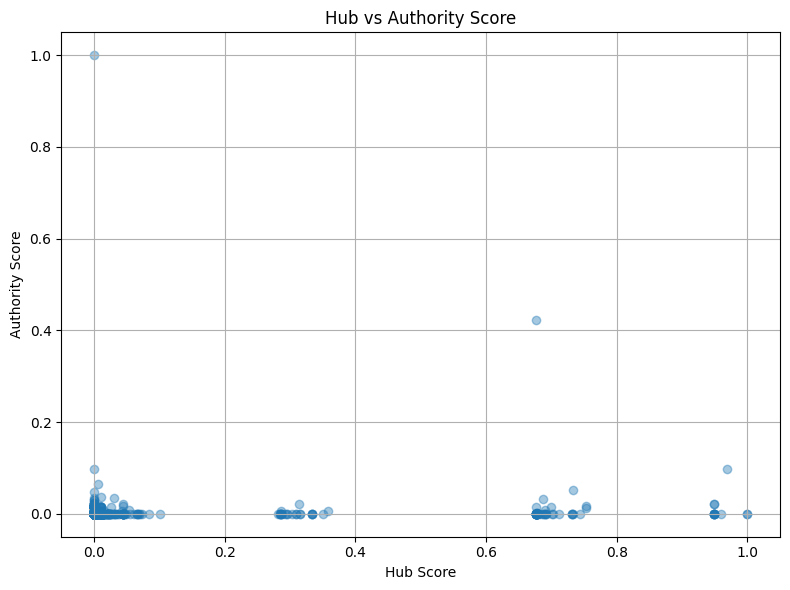

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(hub_scores, authority_scores, alpha=0.4)
plt.xlabel("Hub Score")
plt.ylabel("Authority Score")
plt.title("Hub vs Authority Score")
plt.grid(True)
plt.tight_layout()
plt.show()

Let’s explore which products have the highest hub and authority scores.

In [ ]:
# Pandas for structured the data easily
import pandas as pd

df = pd.DataFrame({
    "id": g_also_bought.vs["name"],
    "title": g_also_bought.vs["title"],
    "category": g_also_bought.vs["category"],
    "hub_score": hub_scores,
    "authority_score": authority_scores
})

# Extract top 10
top10_hubs = df.sort_values(by="hub_score", ascending=False).head(10)
top10_authorities = df.sort_values(by="authority_score", ascending=False).head(10)

# Print results
print("🔺 Top 10 Hub Score:")
print(top10_hubs[["id", "title", "category", "hub_score"]].to_string(index=False))

print("\n🔹 Top 10 Authority Score:")
print(top10_authorities[["id", "title", "category", "authority_score"]].to_string(index=False))

🔺 Top 10 Hub Score:
        id                                                                                                                                                                                                    title    category  hub_score
B0757LNVBT                                      inphic Mouse Wireless Ricaricabile, Mouse Ottico Mini Silenzioso con Clic Mute, 1600 Dpi Ultra Sottile per Notebook, PC, Laptop, Computer, MacBook (Argento Chiaro) electronics   1.000000
B01IVOCDJ2                       AUKEY Lampada da Scrivania a LED 6W, Lampada da Lettura con 3 Livelli di Luminosità, Controllo Touch e Protezione degli Occhi, Angolo Regolabile e Collo Flessibile (Nera, LT-ST1)    lighting   1.000000
B07P84VCNJ Elekin Torcia LED,2000 Lumen Impermeabile Torcia Elettrica,Ricaricabile Torcia con Caricatore USB, 18650 Batteria Ricaricabile, Militare Torcia,CREE XM-L T6 LED, Regolabile 5 Modalità di Illuminazione       tools   0.969555
B07D3XYZDS               Cacciavite Elet

Rank Aggregation is the process of combining multiple ranked lists into a single, consensus ranking. It is commonly used when several sources or criteria provide different rankings of the same items, and the goal is to produce an overall ranking that best represents the collective preferences. This technique is widely applied in fields like information retrieval, recommendation systems, voting theory, and meta-search engines.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df["betweenness"] = betweenness_also_bought

# Calcola i rank (min rank = nodo migliore)
df["hub_rank"] = df["hub_score"].rank(ascending=False)
df["betw_rank"] = df["betweenness"].rank(ascending=False)

# Somma dei rank per aggregazione
df["combined_rank"] = df["hub_rank"] + df["betw_rank"]

# Filtra con soglie (ad esempio top 25% per entrambe)
threshold_hub = df["hub_score"].quantile(0.75)
threshold_betw = df["betweenness"].quantile(0.75)

filtered_df = df[(df["hub_score"] >= threshold_hub) & (df["betweenness"] >= threshold_betw)]

print("🔸 Nods top 10 for combined rank (using the thresholds):")
top_nodes = filtered_df.sort_values("combined_rank").head(10)

for _, row in top_nodes.iterrows():
    print(f"ID: {row['id']} | Title: {row['title']} | Hub: {row['hub_score']:.4f} | Betweenness: {row['betweenness']:.2f} | Combined Rank: {row['combined_rank']:.0f}")

🔸 Nodi top 10 per combined rank (considerando soglie):
ID: B07HH2XQNX | Title: [2 Pezzi]Presa Intelligente, Houzetek Smart Wifi Plug con supporto APP Alexa / Google Home, Wifi programmabile Plug IFTTT Telecomando per voce, Smart Home Plug Wifi per casa | Hub: 0.6777 | Betweenness: 1622.00 | Combined Rank: 222
ID: B00ANIFOOG | Title: Oceanmap - Astuccio porta schede di memoria SD, 22 slot | Hub: 0.0173 | Betweenness: 1567.00 | Combined Rank: 335
ID: B07MR9C3LX | Title: [2019 NEW] Repellente Ultrasuoni per Topi, Insetti, Zanzare, Ratti, Scarafaggi, Mosche,Pulci,Cani- Repeller ultrasonico controllo dei parassiti di Human & Pet Friendly, Niente più Trap, Spray & Bait | Hub: 0.0002 | Betweenness: 3862.00 | Combined Rank: 533
ID: B07BTSSWRM | Title: Aicase WiFi Smart LED buld- [2 pezzi] [E27 7 W] Compatibile con assistente ALEXA, Google Home & Ifttt – smartphone controlled-silve | Hub: 0.0003 | Betweenness: 1863.00 | Combined Rank: 545
ID: B003LHAL8U | Title: Q Connect - Colla Stick da 10g, 

Comparison between PageRank and Authority, since PageRank measures global centrality, while Authority reflects the number of incoming links from good hubs. Therefore, comparing these two metrics can help us understand whether a product is an authoritative niche (high Authority but low PageRank) or a globally central one (high PageRank but low Authority), or ideally both.

In [ ]:
# pagerank_scores = g_also_bought.pagerank(damping=0.85)
df["pagerank"] = pagerank_scores

# Confronto incrociato
df_sorted = df.sort_values(by="pagerank", ascending=False)

print("🔸 Top Authority nodes with corresponding PageRank:")
print(df.sort_values(by="authority_score", ascending=False)[["id", "title", "authority_score", "pagerank"]].head(10))

🔸 Top Authority nodes with corresponding PageRank:
               id                                              title  \
18748  B07QGBVYJK                                               None   
26631  B07P24R81S  Gfone 8 Set di strumenti per manicure per ungh...   
36121  B07P84VCNJ  Elekin Torcia LED,2000 Lumen Impermeabile Torc...   
30008  B07QJVMTPD                                               None   
12063  B07GFT2NS8  Rolsac - Cagliplast Rotolo con Scatola Esterna...   
3528   B07H3MJ88V  Set Pinze 5 Pezzi InLife Strumenti Utensili pe...   
36632  B07Q93X4ZC                                               None   
31768  B07175KK61  AUKEY Multipresa Ciabatta Elettrica con 5 Post...   
35552  B06XZ6322L  Aglaia LED lanterna da campeggio, USB e solare...   
21391  B075FNRX23                                               None   

       authority_score  pagerank  
18748         1.000000  0.000456  
26631         0.421665  0.000212  
36121         0.098373  0.000072  
30008         0.

Often they are over-represented products in 'also bought' reports (e.g. accessories, extensions of other products, combined sets).

In [ ]:
# Calcola degree se non ancora fatto
in_degrees = g_also_bought.indegree()
out_degrees = g_also_bought.outdegree()

# Imposta soglie percentile (adattabili)
threshold_out = np.percentile(out_degrees, 90)
threshold_hub = np.percentile(hub_scores, 90)
threshold_in = np.percentile(in_degrees, 40)  # bassa in-degree
threshold_auth = np.percentile(authority_scores, 40)

gateway_products = []
for v in g_also_bought.vs:
    if (v.outdegree() >= threshold_out and
        v["hub_score"] >= threshold_hub and
        v.indegree() <= threshold_in and
        v["authority_score"] <= threshold_auth):
        gateway_products.append(v)

print(f"Gateway products found: {len(gateway_products)}")

# Visualizza alcuni di essi
for v in gateway_products[:10]:
    print(f"ID: {v['name']} | Title: {v['title']} | Hub: {v['hub_score']:.3f} | OutDeg: {v.outdegree()} | InDeg: {v.indegree()} | Authority: {v['authority_score']:.3f}")


Gateway products found: 1631
ID: B01INRUFGK | Title: AmazonBasics - Cavo patch Ethernet di Cat6 con connettori RJ45, 1,5 m - Pacco da 5 | Hub: 0.000 | OutDeg: 3 | InDeg: 0 | Authority: 0.000
ID: B01M3PY412 | Title: 2 Pezzi Protezione Sedile Auto,Impermeabile Sedile Posteriore Auto Organizzatori 2 x Tasca dell' Organizzatore Tasca iPad,Organizer Bambino per Sedile Auto,Protezione Sedile Auto Bambini(Nero) | Hub: 0.000 | OutDeg: 3 | InDeg: 1 | Authority: 0.000
ID: B07KLTBHXD | Title: Diffusore di Aromi Homasy 500ml Diffusore Oli Essenziali Ultrasuoni Modalità di Sleep Umidificatore Ultrasonico Foschia Fredda LED 7 Colori Autospegnimento Timer Purifucatore d'aria Regalo Perfetto | Hub: 0.000 | OutDeg: 3 | InDeg: 1 | Authority: 0.000
ID: B07Q39W9WD | Title: rokirs Bracciale da Polso al Quarzo analogico Rotondo con Cinturino in Pelle Sintetica Moda Uomo Orologi da Polso | Hub: 0.288 | OutDeg: 3 | InDeg: 0 | Authority: 0.000
ID: B073FW9LWN | Title: Gabel Tintunita & Co Telo Bagno, 100% Coton